In [4]:
from joblib import Parallel, delayed
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import pickle
import sys
from contextlib import suppress, redirect_stdout, redirect_stderr

In [5]:
%load_ext autoreload
%autoreload 2

import sys, types
sys.path.insert(0, '..')  # allow src.* imports when notebook is in notebooks/

from src.data import ingest, loader
from src.analysis import stats, cointegration, halflife

# fx namespace — maintains all existing fx.* calls in this notebook unchanged
fx = types.SimpleNamespace(
    clean_data=ingest.clean_data,
    timeline_info=ingest.timeline_info,
    create_interval_datasets=ingest.create_interval_datasets,
    calculate_returns=ingest.calculate_returns,
    replace_neg_prices=ingest.replace_neg_prices,
    replace_high_prices=ingest.replace_high_prices,
    drop_duplicate_datetimes=ingest.drop_duplicate_datetimes,
    get_beta_lr=stats.get_beta_lr,
    adf_test=stats.adf_test,
    get_train_test=loader.get_train_test,
    get_test_data=loader.get_test_data,
    common_duration=loader.common_duration,
    common_duration_c=loader.common_duration_c,
    forward_fill_df=loader.forward_fill_df,
    get_dynamic_freq=loader.get_dynamic_freq,
    wrap_hurst=cointegration.wrap_hurst,
    batch_process=cointegration.batch_process,
    initial_granger_cointegration=cointegration.initial_granger_cointegration,
    compute_hurst_exponent=cointegration.compute_hurst_exponent,
    get_rolling_half_life=halflife.get_rolling_half_life,
    get_baseline_hedge_ratio_and_half_life=halflife.get_baseline_hedge_ratio_and_half_life,
    analyze_periods=halflife.analyze_periods,
    classify_pair=halflife.classify_pair,
)

import src.data.ingest as parse_histdata


In [3]:
parse_histdata.clean_data()

Replacing 1 rows with non-positive close prices with 0
Replacing 1 rows with close prices above 3.1232 with 1.5616
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 1.8446 with 0.9223
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 296.406 with 148.203
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 4.0662 with 2.0331
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 3.5356 with 1.7678

In [6]:
file_path = '/Volumes/SEAGATE/FX_data/FX_histdata/'
fx_pairs = ["EURUSD", "EURGBP", "USDJPY", "GBPUSD", "USDCHF", "USDCAD", "AUDUSD", "NZDUSD", "EURJPY", "GBPJPY", "EURCHF", "AUDJPY", "EURAUD", "GBPAUD"]
intervals = ['1T', '5T', '10T', '15T', '30T', '1H', '3H', '6H', '1D']

In [5]:
timeline_df = parse_histdata.timeline_info(fx_pairs)
display(timeline_df)

,Pair,Start,End,Missing Minutes,Max Missing Minutes,Percentage Missing
0,EURUSD,2001-01,2023-12,305633,15547.0,2.527773
1,EURGBP,2002-03,2023-12,388973,5882.0,3.388823
2,USDJPY,2000-05,2023-12,376567,15548.0,3.036179
3,GBPUSD,2000-05,2023-12,345669,15546.0,2.787056
4,USDCHF,2000-05,2023-12,337047,19091.0,2.717530
5,USDCAD,2000-06,2023-12,505296,216573.0,4.080162
6,AUDUSD,2000-06,2023-12,417251,79473.0,3.366455
7,NZDUSD,2005-08,2023-12,301344,5883.0,3.117335
8,EURJPY,2002-03,2023-12,129127,5882.0,1.124984
9,GBPJPY,2002-05,2023-12,93632,13059.0,0.821788


### Test period : 2013-2022 (walk-forward validation)
### Training period : start - 2012

* Initial Training period has only been set upto 2012, due to computational and time constraints.

In [ ]:
fx.create_interval_datasets(fx_pairs, intervals, file_path)

Creating 1T datasets for all pairs
Processing EURUSD for 1T interval
Creating 1T dataset for EURUSD
Processing EURGBP for 1T interval
Creating 1T dataset for EURGBP
Processing USDJPY for 1T interval
Creating 1T dataset for USDJPY
Processing GBPUSD for 1T interval
Creating 1T dataset for GBPUSD
Processing USDCHF for 1T interval
Creating 1T dataset for USDCHF
Processing USDCAD for 1T interval
Creating 1T dataset for USDCAD
Processing AUDUSD for 1T interval
Creating 1T dataset for AUDUSD
Processing NZDUSD for 1T interval
Creating 1T dataset for NZDUSD
Processing EURJPY for 1T interval
Creating 1T dataset for EURJPY
Processing GBPJPY for 1T interval
Creating 1T dataset for GBPJPY
Processing EURCHF for 1T interval
Creating 1T dataset for EURCHF
Processing AUDJPY for 1T interval
Creating 1T dataset for AUDJPY
Processing EURAUD for 1T interval
Creating 1T dataset for EURAUD
Processing GBPAUD for 1T interval
Creating 1T dataset for GBPAUD
Creating 5T datasets for all pairs
Processing EURUSD fo

In the code above, following interpretation has been used:
For Datetime t, the data represents the period from t-1 (included) up till t (not included)
Hence while resampling, (label=right, closed=right) have been used.

In [13]:
fx.calculate_returns(fx_pairs, intervals, file_path)

Calculating returns for 1T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 5T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 10T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 15T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 30T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 1H interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 3H interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/1

* Initial Test period for static hedge ratios and half-lives: 2011-01-01 to 2015-12-31

In [356]:
# 1. Visual check - do spreads mean revert?
# Pick a good pair on a good interval and demonstrate mean-reverting nature, while also calculating half-life.
pair1 = eurusd_train
pair2 = eurgbp_train
def plot_spread_diagnostic(pair1, pair2, interval):

    hedge_ratio = fx.get_beta_lr(pair1['Close'], pair2['Close'])
    spread = pair2['Close'] - hedge_ratio * pair1['Close']

    # 3. The SPREAD should be stationary I(0)
    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(spread.dropna(), maxlag=50)
    print(f"ADF p-value: {adf_result[1]:.4f}")
    # If p < 0.05, spread is stationary → cointegrated

    # 4. Calculate half-life on the STATIONARY spread
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread - spread_lag
    spread_ret = spread_diff.dropna()
    beta = fx.get_beta_lr(spread_lag.dropna(), spread_ret.dropna())
    half_life = -np.log(2) / beta
    print(f"Estimated Half-Life of Mean Reversion: {half_life:.2f} periods")
    print(f"Hedge Ratio: {hedge_ratio:.4f}")
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Raw spread
    axes[0].plot(spread.index, spread)
    axes[0].set_title(f'Spread - {interval}')
    axes[0].axhline(spread.mean(), color='red', linestyle='--')
    
    # ACF plot - should decay slowly if mean reverting
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(spread.dropna(), lags=50, ax=axes[1])
    axes[1].set_title('Autocorrelation - slow decay = mean reversion')
    
    # Regression
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(spread_lag.values.reshape(-1,1), spread_ret.values)
    beta = model.coef_[0]
    
    axes[2].scatter(spread_lag, spread_ret, alpha=0.1, s=1)
    axes[2].plot(spread_lag, model.predict(spread_lag.values.reshape(-1,1)), 
                 'r-', label=f'beta={beta:.6f}')
    axes[2].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[2].set_xlabel('Spread(t-1)')
    axes[2].set_ylabel('Spread(t) - Spread(t-1)')
    axes[2].set_title('Mean Reversion Check - negative slope = reversion')
    axes[2].legend()
    
    plt.tight_layout()
    
    if beta >= 0:
        print(f"BETA POSITIVE ({beta:.6f}) - NO MEAN REVERSION")
    else:
        half_life = -np.log(2) / beta
        print(f"Beta: {beta:.6f}, Half-life: {half_life:.2f} bars")
    
    return beta, half_life if beta < 0 else np.inf


beta, half_life = plot_spread_diagnostic(pair1, 
                                    pair2, 
                                    interval)
plt.show()

NameError: name 'eurusd_train' is not defined

In [9]:
print(intervals)

['1T', '5T', '10T', '15T', '30T', '1H', '3H', '6H', '1D']


 Get Hurst exponent for log(price1/price2) of all pairs at same intervals for first 5 years (max. up till 2012)
 Filter combos with H < 0.5 : down to 730 combos ((pair1, pair2) is same as (pair2, pair1))
 Get Granger cointegration results for spread of log(prices) of filtered combos for first 5 years (max. up till 2012)
 Filter combos with pval < 0.01 : down to 268 unique combos of (pair1, pair2, interval)
 Then period (regime) cointegration analysis i.e. before-GFC (2001-2007), during GFC (2008-2012) and post-GFC (2013-2015)
 For trading strategy, enter when spread abs(z-score) > 2.5, TP when spread abs(z-score) < 0.5, SL when spread abs(z-score) > 4.5
- Due to resource constraints, backtests will be done only on intervals >= '30T' i.e. '30T', '1H', '3H', '6H', '1D' 

This would be the first layer layer of filtering pairs.
Currently, there are 1638 unique combinations of (pair1, pair2, interval)
Hurst does not differentiate b/w (pair1, pair2) and (pair2, pair1)
Hence, 819 combinations (data from start till 2012) are input for Hurst, out of which 730 pass.

In [ ]:
hurst_dict = fx.wrap_hurst(fx_pairs, intervals, file_path, 'Close')

Computing Hurst exponent for 1T interval...
EURUSD-EURGBP: H = 0.5083
EURUSD-USDJPY: H = 0.4849
EURUSD-GBPUSD: H = 0.4724
EURUSD-USDCHF: H = 0.4850
EURUSD-USDCAD: H = 0.4823
EURUSD-AUDUSD: H = 0.4704
EURUSD-NZDUSD: H = 0.4885
EURUSD-EURJPY: H = 0.4965
EURUSD-GBPJPY: H = 0.5076
EURUSD-EURCHF: H = 0.5165
EURUSD-AUDJPY: H = 0.3124
EURUSD-EURAUD: H = 0.5312
EURUSD-GBPAUD: H = 0.5077
EURGBP-USDJPY: H = 0.5057
EURGBP-GBPUSD: H = 0.4885
EURGBP-USDCHF: H = 0.5175
EURGBP-USDCAD: H = 0.5135
EURGBP-AUDUSD: H = 0.4966
EURGBP-NZDUSD: H = 0.5137
EURGBP-EURJPY: H = 0.4693
EURGBP-GBPJPY: H = 0.4732
EURGBP-EURCHF: H = 0.4797
EURGBP-AUDJPY: H = 0.3248
EURGBP-EURAUD: H = 0.4821
EURGBP-GBPAUD: H = 0.5076
USDJPY-GBPUSD: H = 0.4900
USDJPY-USDCHF: H = 0.5244
USDJPY-USDCAD: H = 0.5042
USDJPY-AUDUSD: H = 0.4798
USDJPY-NZDUSD: H = 0.4910
USDJPY-EURJPY: H = 0.5107
USDJPY-GBPJPY: H = 0.5359
USDJPY-EURCHF: H = 0.4890
USDJPY-AUDJPY: H = 0.3595
USDJPY-EURAUD: H = 0.4737
USDJPY-GBPAUD: H = 0.4796
GBPUSD-USDCHF: H = 0

In [40]:
hurst_df = pd.DataFrame(
    [[[] for _ in fx_pairs] for _ in fx_pairs],
    index=fx_pairs,
    columns=fx_pairs,
    dtype=object
)

for x in fx_pairs:
    for y in fx_pairs:
        for interval in intervals:
            if hurst_dict[interval].get((x, y)) is not None:
                hurst_df.loc[x, y].append(np.round(hurst_dict[interval].get((x, y)), 3))
                hurst_df.loc[y, x].append(np.round(hurst_dict[interval].get((x, y)), 3))

In [ ]:
with open('./temp/hurst_results.pkl', 'wb') as f:
    pickle.dump(hurst_df, f)

In [4]:
with open('./temp/hurst_results.pkl', 'rb') as f:
    hurst_df = pickle.load(f)

In [41]:
display(hurst_df.head())

,EURUSD,EURGBP,USDJPY,GBPUSD,USDCHF,USDCAD,AUDUSD,NZDUSD,EURJPY,GBPJPY,EURCHF,AUDJPY,EURAUD,GBPAUD
EURUSD,[],"[0.508, 0.526, 0.539, 0.532, 0.545, 0.557, 0.5...","[0.485, 0.492, 0.479, 0.551, 0.552, 0.553, 0.5...","[0.472, 0.472, 0.459, 0.504, 0.491, 0.494, 0.4...","[0.485, 0.491, 0.477, 0.55, 0.551, 0.555, 0.56...","[0.482, 0.488, 0.471, 0.559, 0.553, 0.553, 0.5...","[0.47, 0.468, 0.461, 0.472, 0.468, 0.476, 0.45...","[0.489, 0.498, 0.528, 0.526, 0.533, 0.541, 0.5...","[0.496, 0.485, 0.524, 0.519, 0.529, 0.532, 0.5...","[0.508, 0.515, 0.518, 0.519, 0.526, 0.526, 0.5...","[0.516, 0.507, 0.518, 0.506, 0.517, 0.532, 0.5...","[0.312, 0.288, 0.302, 0.279, 0.294, 0.347, 0.3...","[0.531, 0.537, 0.543, 0.55, 0.557, 0.556, 0.56...","[0.508, 0.51, 0.514, 0.51, 0.515, 0.527, 0.517..."
EURGBP,"[0.508, 0.526, 0.539, 0.532, 0.545, 0.557, 0.5...",[],"[0.506, 0.513, 0.523, 0.517, 0.53, 0.533, 0.53...","[0.489, 0.492, 0.496, 0.495, 0.49, 0.509, 0.49...","[0.517, 0.532, 0.54, 0.535, 0.548, 0.549, 0.56...","[0.514, 0.529, 0.536, 0.534, 0.545, 0.548, 0.5...","[0.497, 0.506, 0.516, 0.51, 0.517, 0.527, 0.53...","[0.514, 0.513, 0.55, 0.542, 0.551, 0.565, 0.57...","[0.469, 0.464, 0.459, 0.462, 0.455, 0.462, 0.4...","[0.473, 0.47, 0.467, 0.466, 0.463, 0.466, 0.44...","[0.48, 0.473, 0.477, 0.467, 0.472, 0.474, 0.45...","[0.325, 0.306, 0.315, 0.303, 0.314, 0.369, 0.3...","[0.482, 0.489, 0.489, 0.491, 0.495, 0.498, 0.4...","[0.508, 0.517, 0.519, 0.524, 0.524, 0.531, 0.5..."
USDJPY,"[0.485, 0.492, 0.479, 0.551, 0.552, 0.553, 0.5...","[0.506, 0.513, 0.523, 0.517, 0.53, 0.533, 0.53...",[],"[0.49, 0.523, 0.527, 0.526, 0.528, 0.537, 0.54...","[0.524, 0.536, 0.54, 0.543, 0.552, 0.544, 0.57...","[0.504, 0.504, 0.509, 0.503, 0.511, 0.516, 0.5...","[0.48, 0.484, 0.472, 0.48, 0.46, 0.469, 0.446,...","[0.491, 0.501, 0.513, 0.527, 0.521, 0.527, 0.5...","[0.511, 0.5, 0.573, 0.568, 0.586, 0.59, 0.612,...","[0.536, 0.535, 0.546, 0.537, 0.557, 0.559, 0.5...","[0.489, 0.482, 0.488, 0.479, 0.49, 0.504, 0.47...","[0.359, 0.338, 0.352, 0.337, 0.352, 0.424, 0.3...","[0.474, 0.48, 0.479, 0.475, 0.471, 0.482, 0.48...","[0.48, 0.479, 0.478, 0.479, 0.473, 0.474, 0.45..."
GBPUSD,"[0.472, 0.472, 0.459, 0.504, 0.491, 0.494, 0.4...","[0.489, 0.492, 0.496, 0.495, 0.49, 0.509, 0.49...","[0.49, 0.523, 0.527, 0.526, 0.528, 0.537, 0.54...",[],"[0.508, 0.529, 0.52, 0.532, 0.519, 0.509, 0.52...","[0.5, 0.53, 0.525, 0.525, 0.526, 0.519, 0.54, ...","[0.479, 0.471, 0.465, 0.471, 0.458, 0.467, 0.4...","[0.492, 0.497, 0.492, 0.5, 0.497, 0.504, 0.489...","[0.487, 0.474, 0.498, 0.497, 0.499, 0.51, 0.50...","[0.504, 0.507, 0.51, 0.508, 0.515, 0.517, 0.51...","[0.503, 0.49, 0.499, 0.491, 0.496, 0.513, 0.49...","[0.326, 0.306, 0.319, 0.3, 0.317, 0.374, 0.33,...","[0.515, 0.522, 0.522, 0.529, 0.532, 0.527, 0.5...","[0.518, 0.517, 0.527, 0.518, 0.53, 0.54, 0.541..."
USDCHF,"[0.485, 0.491, 0.477, 0.55, 0.551, 0.555, 0.56...","[0.517, 0.532, 0.54, 0.535, 0.548, 0.549, 0.56...","[0.524, 0.536, 0.54, 0.543, 0.552, 0.544, 0.57...","[0.508, 0.529, 0.52, 0.532, 0.519, 0.509, 0.52...",[],"[0.51, 0.52, 0.519, 0.528, 0.524, 0.529, 0.536...","[0.485, 0.493, 0.479, 0.49, 0.471, 0.475, 0.46...","[0.5, 0.51, 0.527, 0.535, 0.528, 0.541, 0.541,...","[0.5, 0.493, 0.549, 0.548, 0.559, 0.556, 0.571...","[0.52, 0.521, 0.527, 0.526, 0.534, 0.534, 0.53...","[0.513, 0.502, 0.514, 0.501, 0.514, 0.537, 0.5...","[0.35, 0.329, 0.344, 0.329, 0.342, 0.409, 0.35...","[0.484, 0.491, 0.485, 0.488, 0.482, 0.487, 0.4...","[0.484, 0.496, 0.488, 0.502, 0.488, 0.485, 0.4..."


In [6]:
# Convert dataframe of lists to list of tuples (pair1, pair2, interval) where value < 0.5
combos_filtered = []

for pair1 in hurst_df.index:
    for pair2 in hurst_df.columns:
        values_list = hurst_df.loc[pair1, pair2]
        if isinstance(values_list, list) and len(values_list) > 0:
            for i, value in enumerate(values_list):
                if value < 0.5:
                    combos_filtered.append((pair1, pair2, intervals[i]))

print(f"Total combinations with H < 0.5: {len(combos_filtered)}")
print(f"\nFirst 10 tuples:")
for tup in combos_filtered[:10]:
    print(tup)

Total combinations with H < 0.5: 730

First 10 tuples:
('EURUSD', 'USDJPY', '1T')
('EURUSD', 'USDJPY', '5T')
('EURUSD', 'USDJPY', '10T')
('EURUSD', 'GBPUSD', '1T')
('EURUSD', 'GBPUSD', '5T')
('EURUSD', 'GBPUSD', '10T')
('EURUSD', 'GBPUSD', '30T')
('EURUSD', 'GBPUSD', '1H')
('EURUSD', 'GBPUSD', '3H')
('EURUSD', 'USDCHF', '1T')


Next stage of our pair filtering is the Engle-Granger cointegration.
730 pairs passed the Hurst exponent filter, but since EG differentiates (pair1, pair2) from (pair2, pair1), there are 1460 inputs.
Data for the pairs will be from common start to 2012 or for 5 years, whichever is earlier.
Of these, only those pairs have been selected who have a p-value < 0.01 (268 combinations of (pair1, pair2, interval))

In [142]:
granger_res = []
for batch in fx.batch_process(combos_filtered, 20):
    temp_res = fx.initial_granger_cointegration(fx_pairs, batch, file_path, end_td=pd.Timedelta(days=252*5), end_max=pd.Timestamp('2012-12-31'), n_jobs=1)
    granger_res.append(temp_res)

Running initial Granger cointegration test for EURUSD and USDJPY at interval 1T...
Processing EURUSD and USDJPY at interval 1T...
Running initial Granger cointegration test for EURUSD and USDJPY at interval 5T...
Processing EURUSD and USDJPY at interval 5T...
Running initial Granger cointegration test for EURUSD and USDJPY at interval 10T...
Processing EURUSD and USDJPY at interval 10T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 1T...
Processing EURUSD and GBPUSD at interval 1T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 5T...
Processing EURUSD and GBPUSD at interval 5T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 10T...
Processing EURUSD and GBPUSD at interval 10T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 30T...
Processing EURUSD and GBPUSD at interval 30T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 1H...
P

In [4]:
print(granger_res)
with open('./temp/granger_coint_results.pkl', 'wb') as f:
    pickle.dump(granger_res, f)

NameError: name 'granger_res' is not defined

In [144]:
display(len(granger_res))

Total combinations with H < 0.5: 730

First 10 tuples:
('EURUSD', 'USDJPY', '1T')
('EURUSD', 'USDJPY', '5T')
('EURUSD', 'USDJPY', '10T')
('EURUSD', 'GBPUSD', '1T')
('EURUSD', 'GBPUSD', '5T')
('EURUSD', 'GBPUSD', '10T')
('EURUSD', 'GBPUSD', '30T')
('EURUSD', 'GBPUSD', '1H')
('EURUSD', 'GBPUSD', '3H')
('EURUSD', 'USDCHF', '1T')


In [145]:
# Merge all dataframes in granger_res into one
merged_granger_df = pd.DataFrame(
    [[{} for _ in fx_pairs] for _ in fx_pairs],
    index=fx_pairs,
    columns=fx_pairs
)

for df in granger_res:
    for pair1 in fx_pairs:
        for pair2 in fx_pairs:
            source_dict = df.at[pair1, pair2]
            target_dict = merged_granger_df.at[pair1, pair2]
            target_dict.update(source_dict)

print(f"Merged {len(granger_res)} dataframes")
display(merged_granger_df)

Running initial Granger cointegration test for EURUSD and USDJPY at interval 1T...
Processing EURUSD and USDJPY at interval 1T...
Running initial Granger cointegration test for EURUSD and USDJPY at interval 5T...
Processing EURUSD and USDJPY at interval 5T...
Running initial Granger cointegration test for EURUSD and USDJPY at interval 10T...
Processing EURUSD and USDJPY at interval 10T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 1T...
Processing EURUSD and GBPUSD at interval 1T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 5T...
Processing EURUSD and GBPUSD at interval 5T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 10T...
Processing EURUSD and GBPUSD at interval 10T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 30T...
Processing EURUSD and GBPUSD at interval 30T...
Running initial Granger cointegration test for EURUSD and GBPUSD at interval 1H...
P

In [7]:
with open('./temp/merged_granger_results.pkl', 'rb') as f:
    merged_granger_df = pickle.load(f)

In [8]:
# Find combos with p-value < 0.01
significant_combos = []
threshold_pval = 0.01
for pair1 in merged_granger_df.index:
    for pair2 in merged_granger_df.columns:
        cell_dict = merged_granger_df.at[pair1, pair2]
        if isinstance(cell_dict, dict):
            for interval, pval in cell_dict.items():
                if pval < threshold_pval:
                    significant_combos.append((pair1, pair2, interval, pval))

print(f"Total combinations with p-value < {threshold_pval}: {len(significant_combos)}")
print(f"\nAll significant combinations:")
for combo in significant_combos:
    print(f"{combo[0]}-{combo[1]} at {combo[2]}: p={combo[3]:.4f}")

Total combinations with p-value < 0.01: 268

All significant combinations:
EURUSD-USDJPY at 10T: p=0.0000
EURUSD-GBPUSD at 10T: p=0.0000
EURUSD-GBPUSD at 30T: p=0.0000
EURUSD-GBPUSD at 1H: p=0.0000
EURUSD-GBPUSD at 3H: p=0.0000
EURUSD-USDCHF at 1T: p=0.0090
EURUSD-USDCHF at 5T: p=0.0000
EURUSD-USDCHF at 10T: p=0.0000
EURUSD-USDCAD at 10T: p=0.0000
EURUSD-AUDUSD at 10T: p=0.0000
EURUSD-AUDUSD at 15T: p=0.0000
EURUSD-AUDUSD at 30T: p=0.0000
EURUSD-AUDUSD at 1H: p=0.0000
EURUSD-AUDUSD at 3H: p=0.0000
EURUSD-EURJPY at 1T: p=0.0030
EURGBP-EURJPY at 5T: p=0.0000
EURGBP-EURJPY at 10T: p=0.0010
EURGBP-EURJPY at 15T: p=0.0010
EURGBP-EURJPY at 30T: p=0.0010
EURGBP-EURJPY at 1H: p=0.0010
EURGBP-EURCHF at 5T: p=0.0030
EURGBP-EURCHF at 10T: p=0.0000
EURGBP-EURCHF at 15T: p=0.0000
EURGBP-EURCHF at 30T: p=0.0000
EURGBP-EURCHF at 1H: p=0.0000
EURGBP-EURCHF at 3H: p=0.0000
EURGBP-EURCHF at 6H: p=0.0040
USDJPY-EURCHF at 10T: p=0.0000
USDJPY-EURCHF at 15T: p=0.0000
USDJPY-EURCHF at 30T: p=0.0000
USDJPY-E

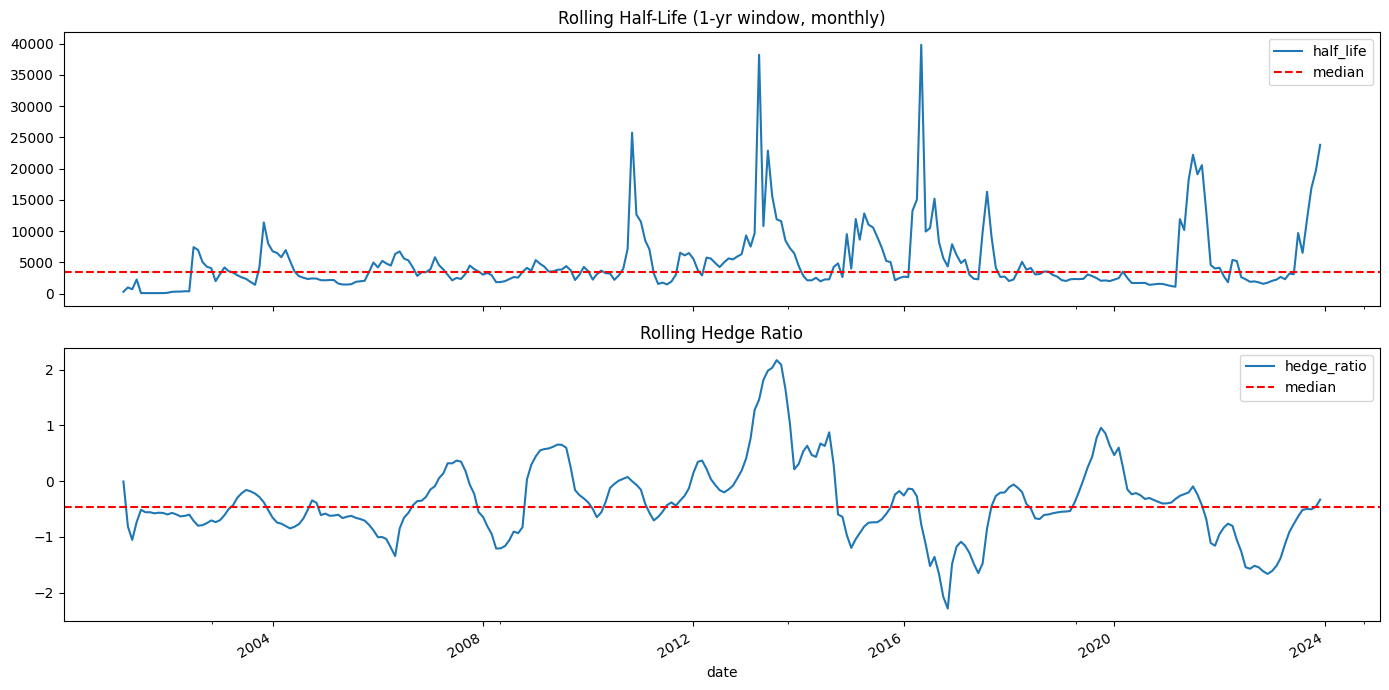

In [9]:
rolling = fx.get_rolling_half_life('EURUSD', 'USDJPY', '10T', file_path)

# Plot both metrics to inspect stability
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
rolling['half_life'].plot(ax=axes[0], title='Rolling Half-Life (1-yr window, monthly)')
axes[0].axhline(rolling['half_life'].median(), color='red', linestyle='--', label='median')
axes[0].legend()
rolling['hedge_ratio'].plot(ax=axes[1], title='Rolling Hedge Ratio')
axes[1].axhline(rolling['hedge_ratio'].median(), color='red', linestyle='--', label='median')
axes[1].legend()
plt.tight_layout()

In [10]:
# For reference, refer to plots in ./halflife_plots
VALID_HALF_LIVES = {
    '1T':  (5,18000),
    '5T':  (5, 4000),
    '10T': (3, 2500),
    '15T': (3,  850),
    '30T': (3,  480),
    '1H':  (2,  450),
    '3H':  (2,  175),
    '6H':  (2,   95),
    '1D':  (2,   35),
}

In [10]:
sample_hr, sample_hl = fx.get_baseline_hedge_ratio_and_half_life('EURUSD', 'USDJPY', '10T', file_path, feature='Close', split_date='2012-12-31')
print(f"Sample Hedge ratio: {sample_hr}")
print(f"Sample half-life up till 2012: {sample_hl}")

Loading data...
Aligning and preprocessing data...
Processing data...
Sample Hedge ratio: -0.5992634793630439
Sample half-life up till 2012: 35930.82970175621


In [11]:
baseline_hl_df = pd.DataFrame(
        [[{} for _ in fx_pairs] for _ in fx_pairs],
        index=fx_pairs,
        columns=fx_pairs
    )
baseline_hr_df = pd.DataFrame(
        [[{} for _ in fx_pairs] for _ in fx_pairs],
        index=fx_pairs,
        columns=fx_pairs
    )
n = len(significant_combos)
for idx, (pair1, pair2, interval, pval) in enumerate(significant_combos):
    print(f"Processing {idx+1}/{n}: {pair1}-{pair2} at {interval}")
    hl, hr = fx.get_baseline_hedge_ratio_and_half_life(pair1, pair2, interval, file_path, feature='Close', split_date='2012-12-31')
    baseline_hl_df.at[pair1, pair2][interval] = hl
    baseline_hr_df.at[pair1, pair2][interval] = hr

Processing 1/268: EURUSD-USDJPY at 10T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 2/268: EURUSD-GBPUSD at 10T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 3/268: EURUSD-GBPUSD at 30T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 4/268: EURUSD-GBPUSD at 1H
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 5/268: EURUSD-GBPUSD at 3H
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 6/268: EURUSD-USDCHF at 1T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 7/268: EURUSD-USDCHF at 5T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 8/268: EURUSD-USDCHF at 10T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 9/268: EURUSD-USDCAD at 10T
Loading data...
Aligning and preprocessing data...
Processing data...
Processing 10/268: EURU

In [12]:
with open('./temp/baseline_half_lives.pkl', 'wb') as f:
    pickle.dump(baseline_hl_df, f)
with open('./temp/baseline_hedge_ratios.pkl', 'wb') as f:
    pickle.dump(baseline_hr_df, f)

In [11]:
with open('./temp/baseline_half_lives.pkl', 'rb') as f:
    baseline_hl_df = pickle.load(f)
with open('./temp/baseline_hedge_ratios.pkl', 'rb') as f:
    baseline_hr_df = pickle.load(f)

In [12]:
display(baseline_hl_df)

,EURUSD,EURGBP,USDJPY,GBPUSD,USDCHF,USDCAD,AUDUSD,NZDUSD,EURJPY,GBPJPY,EURCHF,AUDJPY,EURAUD,GBPAUD
EURUSD,{},{},{'10T': -0.5992634793630439},"{'10T': 0.40723166826255097, '30T': 0.40723840...","{'1T': -1.0414998853877373, '5T': -1.041500965...",{'10T': -0.9310640580843818},"{'10T': 1.2361411957326964, '15T': 1.236148949...",{},{'1T': 0.34213091534686263},{},{},{},{},{}
EURGBP,{},{},{},{},{},{},{},{},"{'5T': -0.48956491331726726, '10T': -0.4895708...",{},"{'5T': -0.45154011075955564, '10T': -0.4515405...",{},{},{}
USDJPY,{},{},{},{},{},{},{},{},{},{},"{'10T': 0.5343843169248975, '15T': 0.534384468...",{},{},{}
GBPUSD,{},{},{},{},{},{},"{'10T': 0.86196475370839, '15T': 0.86196386137...",{},{},{},"{'10T': 0.6191477048644103, '15T': 0.619140355...",{},{},{}
USDCHF,"{'1T': -0.7039289078427979, '5T': -0.703929473...",{},{},{},{},{},"{'10T': -1.1065237167349051, '15T': -1.1065220...",{},{'5T': 0.33455503815413},{},{'6H': 0.4299813877994204},{},{},{}
USDCAD,{},{},{},{},{},{},"{'10T': -1.3301935861608858, '15T': -1.3301922...",{},{},{},"{'15T': 0.25864528216066435, '3H': 0.258650200...",{},{},{}
AUDUSD,{},{},"{'10T': -0.4930533615865934, '15T': -0.4930551...","{'10T': 0.18390377757808887, '15T': 0.18390498...","{'10T': -0.7782717182269968, '15T': -0.7782731...","{'10T': -0.6523369542316539, '15T': -0.6523371...",{},{},{},{},{'15T': -0.2860411317415458},{},{},{}
NZDUSD,{},{},{},{},{},{},{},{},{},{},{},{},{},{}
EURJPY,"{'1T': 0.23258414495930416, '5T': 0.2325801990...","{'5T': -0.3459406245027639, '10T': -0.34595159...",{},{},{},{},{},{},{},{},"{'10T': 0.6406325375298609, '15T': 0.640631978...",{},{},{}
GBPJPY,{},{},{},{},{},{},{},{},"{'1T': 0.5643003691110069, '5T': 0.56429864136...",{},"{'10T': 0.4006447833467489, '15T': 0.400643753...",{},{},{}


In [13]:
# Count half-lives by category
within_range = 0
out_of_range_positive = 0
negative = 0

for pair1 in baseline_hl_df.index:
    for pair2 in baseline_hl_df.columns:
        cell_dict = baseline_hl_df.at[pair1, pair2]
        if isinstance(cell_dict, dict):
            for interval, hl in cell_dict.items():
                if interval in VALID_HALF_LIVES:
                    min_hl, max_hl = VALID_HALF_LIVES[interval]

                    if hl < 0:
                        negative += 1
                    elif min_hl <= hl <= max_hl:
                        within_range += 1
                    else:  # hl > 0 but outside range
                        out_of_range_positive += 1

total = within_range + out_of_range_positive + negative

print(f"Half-life Analysis:")
print(f"{'='*50}")
print(f"Total combinations analyzed: {total}")
print(f"Within valid range: {within_range} ({within_range/total*100:.1f}%)")
print(f"Out of range (positive): {out_of_range_positive} ({out_of_range_positive/total*100:.1f}%)")
print(f"Negative half-lives: {negative} ({negative/total*100:.1f}%)")

Half-life Analysis:
Total combinations analyzed: 268
Within valid range: 0 (0.0%)
Out of range (positive): 165 (61.6%)
Negative half-lives: 103 (38.4%)


| Tier | Definition |
|---|---|
| **TIER_1** | Structural relationship that broke during crisis and recovered post-crisis |
| **TIER_2** | New relationship that appears only post-crisis |
| **TIER_3** | Legacy relationship that existed pre-crisis but did not persist post-crisis |
| **TIER_4** | Most stable relationship; valid in pre-, crisis-, and post-crisis periods |
| **REJECT** | Does not satisfy any tier condition |

In [14]:
periods = {
    'pre_crisis':  (pd.to_datetime('2001-01-01'), pd.to_datetime('2007-12-31')),  # 4-5 years depending on pair
    'crisis':      (pd.to_datetime('2008-01-01'), pd.to_datetime('2009-12-31')),  # 2 years
    'post_crisis': (pd.to_datetime('2010-01-01'), pd.to_datetime('2015-12-31'))   # 6 years
}
n = len(significant_combos)
pair_tier_results = {}
for idx, (pair1, pair2, interval, pval) in enumerate(significant_combos):
    print(f"Processing {idx+1}/{n}: {pair1}-{pair2} at {interval}")
    period_analysis = fx.analyze_periods(pair1, pair2, periods, interval, file_path, VALID_HALF_LIVES, max_period_end=pd.to_datetime('2015-12-31'))
    pair_tier = fx.classify_pair(period_analysis)
    pair_tier_results[(pair1, pair2, interval)] = pair_tier

tier_data = []
for (pair1, pair2, interval), tier in pair_tier_results.items():
    tier_data.append({
        'Pair1': pair1,
        'Pair2': pair2,
        'Interval': interval,
        'Tier': tier
    })

tier_df = pd.DataFrame(tier_data)

tier_counts = tier_df['Tier'].value_counts().sort_index()

print("Tier Distribution:")
print("="*50)
tier_pct = (tier_counts / tier_counts.sum() * 100).round(1)
summary_table = pd.DataFrame({
    'Count': tier_counts,
    'Percentage': tier_pct
})
display(summary_table)

Processing 1/268: EURUSD-USDJPY at 10T
Processing 2/268: EURUSD-GBPUSD at 10T
Processing 3/268: EURUSD-GBPUSD at 30T
Processing 4/268: EURUSD-GBPUSD at 1H
Processing 5/268: EURUSD-GBPUSD at 3H
Processing 6/268: EURUSD-USDCHF at 1T
Processing 7/268: EURUSD-USDCHF at 5T
Processing 8/268: EURUSD-USDCHF at 10T
Processing 9/268: EURUSD-USDCAD at 10T
Processing 10/268: EURUSD-AUDUSD at 10T
Processing 11/268: EURUSD-AUDUSD at 15T
Processing 12/268: EURUSD-AUDUSD at 30T
Processing 13/268: EURUSD-AUDUSD at 1H
Processing 14/268: EURUSD-AUDUSD at 3H
Processing 15/268: EURUSD-EURJPY at 1T
Processing 16/268: EURGBP-EURJPY at 5T
Processing 17/268: EURGBP-EURJPY at 10T
Processing 18/268: EURGBP-EURJPY at 15T
Processing 19/268: EURGBP-EURJPY at 30T
Processing 20/268: EURGBP-EURJPY at 1H
Processing 21/268: EURGBP-EURCHF at 5T
Processing 22/268: EURGBP-EURCHF at 10T
Processing 23/268: EURGBP-EURCHF at 15T
Processing 24/268: EURGBP-EURCHF at 30T
Processing 25/268: EURGBP-EURCHF at 1H
Processing 26/268: E

,Count,Percentage
Tier,,
REJECT,89,33.2
TIER_3,179,66.8


In [16]:
periods = {
    'pre_crisis':  (pd.to_datetime('2001-01-01'), pd.to_datetime('2007-12-31')),  # 4-5 years depending on pair
    'crisis':      (pd.to_datetime('2008-01-01'), pd.to_datetime('2012-12-31')),  # 5 years
    'post_crisis': (pd.to_datetime('2013-01-01'), pd.to_datetime('2015-12-31'))   # 2 years
}

pair_tier_results = {}
for idx, (pair1, pair2, interval, pval) in enumerate(significant_combos):
    print(f"Processing {idx+1}/{n}: {pair1}-{pair2} at {interval}")
    period_analysis = fx.analyze_periods(pair1, pair2, periods, interval, file_path, VALID_HALF_LIVES, max_period_end=pd.to_datetime('2015-12-31'))
    pair_tier = fx.classify_pair(period_analysis)
    pair_tier_results[(pair1, pair2, interval)] = pair_tier

tier_data = []
for (pair1, pair2, interval), tier in pair_tier_results.items():
    tier_data.append({
        'Pair1': pair1,
        'Pair2': pair2,
        'Interval': interval,
        'Tier': tier
    })

tier_df = pd.DataFrame(tier_data)

tier_counts = tier_df['Tier'].value_counts().sort_index()

print("Tier Distribution:")
print("="*50)
tier_pct = (tier_counts / tier_counts.sum() * 100).round(1)
summary_table = pd.DataFrame({
    'Count': tier_counts,
    'Percentage': tier_pct
})
display(summary_table)

Processing 1/268: EURUSD-USDJPY at 10T
Processing 2/268: EURUSD-GBPUSD at 10T
Processing 3/268: EURUSD-GBPUSD at 30T
Processing 4/268: EURUSD-GBPUSD at 1H
Processing 5/268: EURUSD-GBPUSD at 3H
Processing 6/268: EURUSD-USDCHF at 1T
Processing 7/268: EURUSD-USDCHF at 5T
Processing 8/268: EURUSD-USDCHF at 10T
Processing 9/268: EURUSD-USDCAD at 10T
Processing 10/268: EURUSD-AUDUSD at 10T
Processing 11/268: EURUSD-AUDUSD at 15T
Processing 12/268: EURUSD-AUDUSD at 30T
Processing 13/268: EURUSD-AUDUSD at 1H
Processing 14/268: EURUSD-AUDUSD at 3H
Processing 15/268: EURUSD-EURJPY at 1T
Processing 16/268: EURGBP-EURJPY at 5T
Processing 17/268: EURGBP-EURJPY at 10T
Processing 18/268: EURGBP-EURJPY at 15T
Processing 19/268: EURGBP-EURJPY at 30T
Processing 20/268: EURGBP-EURJPY at 1H
Processing 21/268: EURGBP-EURCHF at 5T
Processing 22/268: EURGBP-EURCHF at 10T
Processing 23/268: EURGBP-EURCHF at 15T
Processing 24/268: EURGBP-EURCHF at 30T
Processing 25/268: EURGBP-EURCHF at 1H
Processing 26/268: E

,Count,Percentage
Tier,,
REJECT,86,32.1
TIER_1,2,0.7
TIER_2,3,1.1
TIER_3,177,66.0


In [17]:
pd.crosstab(tier_df['Tier'], tier_df['Interval'])

Interval,10T,15T,1D,1H,1T,30T,3H,5T,6H
Tier,,,,,,,,,
REJECT,14,16,4,12,0,16,11,2,11
TIER_1,0,0,2,0,0,0,0,0,0
TIER_2,0,0,3,0,0,0,0,0,0
TIER_3,24,22,14,19,16,19,23,17,23


In [18]:
final_combos = tier_df[tier_df['Tier'] != 'REJECT']
final_combos = final_combos.groupby('Interval').apply(lambda x: list(zip(x['Pair1'], x['Pair2']))).to_dict()
print(f"Intervals available: {list(final_combos.keys())}")
for interval, pairs in final_combos.items():
    print(f"{interval}: {pairs}")
print(type(final_combos))

Intervals available: ['10T', '15T', '1D', '1H', '1T', '30T', '3H', '5T', '6H']
10T: [('EURUSD', 'GBPUSD'), ('EURUSD', 'USDCHF'), ('EURUSD', 'AUDUSD'), ('EURGBP', 'EURCHF'), ('USDJPY', 'EURCHF'), ('GBPUSD', 'EURCHF'), ('EURJPY', 'EURCHF'), ('GBPJPY', 'EURCHF'), ('EURCHF', 'GBPUSD'), ('EURCHF', 'EURJPY'), ('EURCHF', 'GBPJPY'), ('EURCHF', 'EURAUD'), ('AUDJPY', 'EURUSD'), ('AUDJPY', 'EURGBP'), ('AUDJPY', 'USDJPY'), ('AUDJPY', 'GBPUSD'), ('AUDJPY', 'USDCHF'), ('AUDJPY', 'USDCAD'), ('AUDJPY', 'AUDUSD'), ('AUDJPY', 'EURJPY'), ('AUDJPY', 'GBPJPY'), ('AUDJPY', 'EURCHF'), ('AUDJPY', 'EURAUD'), ('EURAUD', 'EURCHF')]
15T: [('GBPUSD', 'EURCHF'), ('USDCAD', 'EURCHF'), ('AUDUSD', 'EURCHF'), ('EURJPY', 'EURCHF'), ('GBPJPY', 'EURCHF'), ('EURCHF', 'GBPUSD'), ('EURCHF', 'USDCAD'), ('EURCHF', 'AUDUSD'), ('EURCHF', 'EURJPY'), ('EURCHF', 'GBPJPY'), ('AUDJPY', 'EURUSD'), ('AUDJPY', 'EURGBP'), ('AUDJPY', 'USDJPY'), ('AUDJPY', 'GBPUSD'), ('AUDJPY', 'USDCHF'), ('AUDJPY', 'USDCAD'), ('AUDJPY', 'AUDUSD'), ('AUDJP

In [20]:
import importlib
import src.backtest.kalman as bk
importlib.reload(bk)

<module 'backtest_kalman' from '/Users/stark/Desktop/Projects/FX_Statistical_Arbitrage/backtest_kalman.py'>

In [21]:
def profit_factor(x):
    wins = x[x > 0].sum()
    losses = abs(x[x < 0].sum())
    return wins / losses if losses > 0 else np.inf

def final_filter(trades_df):
    tmp_list = []
    oos_tested = trades_df[~trades_df['is_paper']].groupby('pair').agg(
        n=('dollar_pnl_net', 'count'),
        win_rate=('dollar_pnl_net', lambda x: (x >= 0).mean()),
        total_pnl=('dollar_pnl_net', 'sum'),
        profit_factor=('dollar_pnl_net', profit_factor),
        avg_pnl=('dollar_pnl_net', 'mean'),
        pnl_std=('dollar_pnl_net', 'std'),
    ).sort_values('total_pnl', ascending=False)

    # Filter: profit_factor > 1.3 AND n >= 15 (minimum trade count)
    test_pairs = oos_tested[
        # (oos_tested['profit_factor'] > 1.1) 
        # & (oos_tested['n'] >= 15)
        (oos_tested['n'] > 0)
    ].index.to_list()

    for item in test_pairs:
        p1 = item.split('/')[0]
        p2 = item.split('/')[1]
        # if p1 == 'EURCHF' or p2 == 'EURCHF':
        #     continue
        tmp_list.append((p1, p2))
    return tmp_list, oos_tested

In [31]:
curr_interval = '1D'
oos_filtered_pairs = {}
oos_filtered_pairs[curr_interval] = {}
DELTA_SEARCH_SPACE = {
    '1D':  [1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1],
    '6H':  [5e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5],
    '3H':  [1e-8, 5e-8, 1e-7, 5e-7, 1e-6, 5e-6],
    '1H':  [1e-9, 5e-9, 1e-8, 5e-8, 1e-7, 5e-7],
    '30T': [1e-9, 5e-9, 1e-8, 5e-8, 1e-7, 5e-7],
}
for delta in DELTA_SEARCH_SPACE[curr_interval]:
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            pairs        = final_combos[curr_interval],
            interval     = curr_interval,
            test_start   = '2013-01-01',
            test_end     = '2015-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )
    oos_filtered_pairs[curr_interval][delta], oos_tested = final_filter(trades_df)
    print(oos_tested)
    print(oos_filtered_pairs[curr_interval][delta])
    print()
    print("oos_filtered_pairs:")
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            # pairs        = final_combos[curr_interval],
            pairs       = oos_filtered_pairs[curr_interval][delta],
            interval     = curr_interval,
            test_start   = '2016-01-01',
            test_end     = '2022-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )
    print("Unfiltered pairs:")
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            pairs        = final_combos[curr_interval],
            # pairs       = oos_filtered_pairs[curr_interval],
            interval     = curr_interval,
            test_start   = '2016-01-01',
            test_end     = '2022-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )

Universe backtest: 19 @ 1D
Period: 2013-01-01 - 2015-12-31
Loaded 19/19 successfully

  Portfolio Metrics:
{'avg_bars_held': np.float64(3.55),
 'avg_trade_pnl_net': np.float64(-27.5184),
 'cagr_pct': np.float64(-0.0966),
 'final_portfolio_value': np.float64(997110.57),
 'initial_capital': 1000000.0,
 'kalman_delta': 1e-07,
 'kalman_warmup_bars': 30,
 'max_drawdown_pct': np.float64(0.3719),
 'n_bars': 936,
 'n_pairs': 14,
 'n_paper_trades': 42,
 'n_real_trades': 105,
 'portfolio_turnover': np.float64(1.2174),
 'real_losses': 64,
 'real_win_rate': 0.3905,
 'real_wins': 41,
 'sharpe_ratio': np.float64(-0.595),
 'test_years': 3.0,
 'total_return_pct': np.float64(-0.2889),
 'total_txn_costs': np.float64(182.05)}

  Saved: ./backtest_results_kalman/equity_curve_1D.csv
  Saved: ./backtest_results_kalman/trades_1D.csv
                n  win_rate    total_pnl  profit_factor     avg_pnl  \
pair                                                                  
EURCHF/EURGBP   4  1.000000   565.74

# 1D Interval: Kalman Delta Grid Search Summary

## Performance Across Delta Values

| Delta | Train Sharpe (2013-2015) | OOS Filtered Sharpe (2016-2022) | OOS Unfiltered Sharpe (2016-2022) |
|-------|--------------------------:|--------------------------------:|----------------------------------:|
| **1e-7**  | -0.5950 | -0.5337 | -0.5758 |
| **5e-7**  | -0.0007 | -0.0101 | -0.1220 |
| **1e-6**  | -0.4917 | -0.0889 | -0.2086 |
| **5e-6**  | -0.2031 | -0.1703 | -0.1724 |
| **1e-5**  | -0.0403 | -0.0582 | -0.0573 |
| **5e-5**  | -0.2595 | -0.1090 | -0.1662 |
| **1e-4**  | -0.3860 | -0.0962 | -0.2060 |
| **5e-4**  | -0.3094 | 0.0626 | -0.0333 |
| **1e-3**  | -0.8302 | 0.1202 | 0.0262 |
| **5e-3**  | -0.5537 | -0.3148 | -0.0519 |
| **1e-2**  | -0.3688 | -0.2161 | -0.0713 |
| **5e-2**  | -0.5585 | 0.2589 | **0.1682** ✅ |
| **1e-1**  | -0.5546 | **0.2795** ✅ | 0.1279 |
| **5e-1**  | -0.5848 | -0.6051 | -0.0498 |

---

## Key Findings

### 1. **Optimal Delta is in the Higher-Delta Regime**
- **Best OOS filtered delta:** **1e-1**
- **Best OOS unfiltered delta:** **5e-2**
- Lower deltas do not hold up out-of-sample.

### 2. **Best Filtered Configuration = 1e-1**
- OOS Sharpe (Filtered): **0.2795**
- CAGR: **0.0084%**
- Total Return: **0.0585%**
- MaxDD: **0.0366%**
- **50 trades over 7 years**
- Win rate: **68.0%**
- Traded pair count: **4**

### 3. **Best Unfiltered Configuration = 5e-2**
- OOS Sharpe (Unfiltered): **0.1682**
- CAGR: **0.0061%**
- Total Return: **0.0426%**
- MaxDD: **0.0500%**
- **84 trades over 7 years**
- Win rate: **57.1%**
- Traded pair count: **7**

### 4. **Filtering Helps Mainly at Higher Deltas**
- At **5e-2**, filtering improves Sharpe from **0.1682 → 0.2589**
- At **1e-1**, filtering improves Sharpe from **0.1279 → 0.2795**
- At most lower deltas, both filtered and unfiltered remain negative

### 5. **Revised Sweet Spot: 5e-2 to 1e-1**
- Small deltas (**1e-7 to 1e-2**) are mostly OOS negative
- Performance turns positive at **5e-4** and **1e-3**, but only modestly
- Peak results occur at **5e-2** and **1e-1**
- Results deteriorate again at **5e-1**

### 6. **Train Sharpe is Not a Reliable Selector**
- Best train result is **5e-7 = -0.0007**, but OOS remains weak
- Best OOS deltas (**5e-2**, **1e-1**) have poor training Sharpe
- In-sample performance does not generalize well here

---

## Recommendation
**Deploy `1e-1` for the 1D interval if pair filtering is used.**  
**Deploy `5e-2` if trading the unfiltered universe.**

In [32]:
curr_interval = '6H'
# oos_filtered_pairs = {}
oos_filtered_pairs[curr_interval] = {}
DELTA_SEARCH_SPACE = {
    '1D':  [1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5],
    '6H':  [5e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1],
    '3H':  [1e-8, 5e-8, 1e-7, 5e-7, 1e-6, 5e-6],
    '1H':  [1e-9, 5e-9, 1e-8, 5e-8, 1e-7, 5e-7],
    '30T': [1e-9, 5e-9, 1e-8, 5e-8, 1e-7, 5e-7],
}
for delta in DELTA_SEARCH_SPACE[curr_interval]:
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            pairs        = final_combos[curr_interval],
            interval     = curr_interval,
            test_start   = '2013-01-01',
            test_end     = '2015-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )
    oos_filtered_pairs[curr_interval][delta], oos_tested = final_filter(trades_df)
    print(oos_tested)
    print(oos_filtered_pairs[curr_interval][delta])
    print()
    print("oos_filtered_pairs:")
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            # pairs        = final_combos[curr_interval],
            pairs       = oos_filtered_pairs[curr_interval][delta],
            interval     = curr_interval,
            test_start   = '2016-01-01',
            test_end     = '2022-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )
    print("Unfiltered pairs:")
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            pairs        = final_combos[curr_interval],
            # pairs       = oos_filtered_pairs[curr_interval],
            interval     = curr_interval,
            test_start   = '2016-01-01',
            test_end     = '2022-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )

Universe backtest: 23 @ 6H
Period: 2013-01-01 - 2015-12-31
Loaded 23/23 successfully

  Portfolio Metrics:
{'avg_bars_held': np.float64(2.18),
 'avg_trade_pnl_net': np.float64(3.887),
 'cagr_pct': np.float64(0.0022),
 'final_portfolio_value': np.float64(1000066.08),
 'initial_capital': 1000000.0,
 'kalman_delta': 5e-08,
 'kalman_warmup_bars': 60,
 'max_drawdown_pct': np.float64(0.0115),
 'n_bars': 3260,
 'n_pairs': 5,
 'n_paper_trades': 4,
 'n_real_trades': 17,
 'portfolio_turnover': np.float64(0.4575),
 'real_losses': 10,
 'real_win_rate': 0.4118,
 'real_wins': 7,
 'sharpe_ratio': np.float64(0.2486),
 'test_years': 3.0,
 'total_return_pct': np.float64(0.0066),
 'total_txn_costs': np.float64(68.51)}

  Saved: ./backtest_results_kalman/equity_curve_6H.csv
  Saved: ./backtest_results_kalman/trades_6H.csv
               n  win_rate  total_pnl  profit_factor    avg_pnl    pnl_std
pair                                                                      
AUDJPY/USDCAD  3  0.666667  98.78895

# 6H Interval: Kalman Delta Grid Search Summary

## Performance Across Delta Values

| Delta | Train Sharpe (2013-2015) | OOS Filtered Sharpe (2016-2022) | OOS Unfiltered Sharpe (2016-2022) |
|-------|--------------------------:|--------------------------------:|----------------------------------:|
| **5e-8**  | 0.249 | -0.327 | -0.823 |
| **1e-7**  | -0.110 | -0.667 | -1.340 |
| **5e-7**  | -1.608 | -1.153 | -1.367 |
| **1e-6**  | -1.272 | -0.434 | -0.595 |
| **5e-6**  | -1.125 | -0.415 | -0.518 |
| **1e-5**  | -1.075 | -0.377 | -0.430 |
| **5e-5**  | -1.125 | -0.023 | -0.178 |
| **1e-4**  | -1.200 | 0.094 | -0.175 |
| **5e-4**  | -0.216 | -0.014 | 0.304 |
| **1e-3**  | -0.268 | 0.031 | 0.261 |
| **5e-3**  | -0.723 | 0.527 | **0.435** ✅ |
| **1e-2**  | -0.799 | **0.530** ✅ | 0.297 |
| **5e-2**  | -0.417 | 0.233 | -0.383 |
| **1e-1**  | -0.486 | -0.111 | -0.344 |
| **5e-1**  | -0.542 | -0.050 | -0.167 |

---

## Key Findings

### 1. **Optimal Delta is Higher Than Previously Thought**
- **Best OOS filtered delta:** **1e-2**
- **Best OOS unfiltered delta:** **5e-3**
- The earlier **5e-6** conclusion is no longer valid after the expanded grid search.

### 2. **Best Filtered Configuration = 1e-2**
- OOS Sharpe (Filtered): **0.5297**  
- CAGR: **0.0166%**
- Total Return: **0.1165%**
- MaxDD: **0.0498%**
- **150 trades over 7 years**
- Win rate: **54.0%**
- Traded pair count: **4**

### 3. **Best Unfiltered Configuration = 5e-3**
- OOS Sharpe (Unfiltered): **0.4352**
- CAGR: **0.0223%**
- Total Return: **0.1561%**
- MaxDD: **0.0640%**
- **256 trades over 7 years**
- Win rate: **53.1%**
- Traded pair count: **12**

### 4. **Filtering Helps, But Not Uniformly**
- At **1e-2**, filtering improves Sharpe from **0.2972 → 0.5297**
- At **5e-3**, filtering improves Sharpe from **0.4352 → 0.5273**
- At **5e-4** and **1e-3**, filtering is worse than unfiltered
- Filtering is therefore **delta-dependent**, not universally beneficial

### 5. **Revised Sweet Spot: 5e-3 to 1e-2**
- Very small deltas (**5e-8 to 1e-5**) are mostly OOS negative
- Performance recovers around **1e-4 to 1e-3**
- **Peak performance occurs at 5e-3 and 1e-2**
- Results deteriorate again beyond **5e-2**

### 6. **Overfitting Signal at Low Deltas**
- **5e-8:** Train Sharpe **0.249** → OOS Filtered **-0.327**, Unfiltered **-0.823**
- Stronger in-sample results at low deltas do **not** generalize
- The best OOS deltas (**5e-3**, **1e-2**) both have weak/negative training Sharpe
- Train Sharpe alone is not a reliable selector here

---

## Recommendation
**Deploy `1e-2` for the 6H interval if pair filtering is used.**  
**Deploy `5e-3` if trading the unfiltered universe.**

In [33]:
curr_interval = '3H'
# oos_filtered_pairs = {}
oos_filtered_pairs[curr_interval] = {}
DELTA_SEARCH_SPACE = {
    '1D':  [1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5],
    '6H':  [5e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5],
    '3H':  [1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2],
    '1H':  [1e-9, 5e-9, 1e-8, 5e-8, 1e-7, 5e-7],
    '30T': [1e-9, 5e-9, 1e-8, 5e-8, 1e-7, 5e-7],
}
for delta in DELTA_SEARCH_SPACE[curr_interval]:
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            pairs        = final_combos[curr_interval],
            interval     = curr_interval,
            test_start   = '2010-01-01',
            test_end     = '2015-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )
    oos_filtered_pairs[curr_interval][delta], oos_tested = final_filter(trades_df)
    print(oos_tested)
    print(oos_filtered_pairs[curr_interval][delta])
    print()
    print("oos_filtered_pairs:")
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            # pairs        = final_combos[curr_interval],
            pairs       = oos_filtered_pairs[curr_interval][delta],
            interval     = curr_interval,
            test_start   = '2016-01-01',
            test_end     = '2022-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )
    print("Unfiltered pairs:")
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            pairs        = final_combos[curr_interval],
            # pairs       = oos_filtered_pairs[curr_interval],
            interval     = curr_interval,
            test_start   = '2016-01-01',
            test_end     = '2022-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )

Universe backtest: 23 @ 3H
Period: 2010-01-01 - 2015-12-31
Loaded 23/23 successfully

  Portfolio Metrics:
{'avg_bars_held': np.float64(2.66),
 'avg_trade_pnl_net': np.float64(-3.4246),
 'cagr_pct': np.float64(-0.0183),
 'final_portfolio_value': np.float64(998900.71),
 'initial_capital': 1000000.0,
 'kalman_delta': 1e-07,
 'kalman_warmup_bars': 80,
 'max_drawdown_pct': np.float64(0.226),
 'n_bars': 12744,
 'n_pairs': 15,
 'n_paper_trades': 85,
 'n_real_trades': 321,
 'portfolio_turnover': np.float64(4.2879),
 'real_losses': 140,
 'real_win_rate': 0.5639,
 'real_wins': 181,
 'sharpe_ratio': np.float64(-0.2043),
 'test_years': 6.0,
 'total_return_pct': np.float64(-0.1099),
 'total_txn_costs': np.float64(1285.28)}

  Saved: ./backtest_results_kalman/equity_curve_3H.csv
  Saved: ./backtest_results_kalman/trades_3H.csv
                n  win_rate    total_pnl  profit_factor    avg_pnl     pnl_std
pair                                                                          
AUDJPY/USDCAD  5

## Updated 3H Grid-Search Readout (from your latest run)

Your new results **invalidate** the earlier 3H conclusion (`1e-5` winner).  
With this run (`kalman_warmup_bars=80`, universe 23), 3H is mostly negative OOS.

### Sharpe snapshot

| Delta | Train Sharpe | OOS Filtered Sharpe | OOS Unfiltered Sharpe |
|---:|---:|---:|---:|
| 1e-7 | -0.2043 | -0.9126 | -0.8688 |
| 5e-7 | -0.4066 | -1.0109 | -0.9476 |
| 1e-6 | -0.2039 | -0.5933 | -0.5639 |
| 5e-6 | -0.0729 | -0.3193 | -0.2881 |
| 1e-5 | 0.0323 | -0.5277 | -0.5200 |
| 5e-5 | 0.1060 | -0.5325 | -0.5325 |
| 1e-4 | 0.0099 | -0.4428 | -0.4428 |
| 5e-4 | 0.4401 | -0.0082 | **-0.0226** (best unfiltered) |
| 1e-3 | -0.0453 | **0.1065** (best filtered) | -0.4337 |
| 5e-3 | -0.1310 | -0.1374 | -0.1371 |
| 1e-2 | 0.5327 | -0.7014 | -0.4423 |
| 5e-2 | 0.2647 | -0.4560 | -0.5053 |

## Key points

- **Best filtered:** `1e-3` (Sharpe `0.1065`, very small edge).
- **Best unfiltered:** `5e-4` (Sharpe `-0.0226`, still negative).
- No robust positive unfiltered setup in this run.
- Strong train Sharpe at `5e-4` / `1e-2` does **not** generalize.

## Practical recommendation

- For 3H, use **`1e-3` only if filtered-pair workflow is enforced**.
- Otherwise, treat 3H as **not deployable** under current config and re-check:
  - `final_filter` criteria (currently very loose: `n > 0`)
  - transaction cost assumptions
  - consistency of train/test pair set construction.

If needed, a replacement markdown cell for the 3H summary in eda.ipynb can be generated.

In [34]:
curr_interval = '1H'
# oos_filtered_pairs = {}
oos_filtered_pairs[curr_interval] = {}
DELTA_SEARCH_SPACE = {
    '1D':  [1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5],
    '6H':  [5e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5],
    '3H':  [1e-8, 5e-8, 1e-7, 5e-7, 1e-6, 5e-6],
    '1H':  [1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3],
    '30T': [1e-9, 5e-9, 1e-8, 5e-8, 1e-7, 5e-7],
}
for delta in DELTA_SEARCH_SPACE[curr_interval]:
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            pairs        = final_combos[curr_interval],
            interval     = curr_interval,
            test_start   = '2010-01-01',
            test_end     = '2015-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )
    oos_filtered_pairs[curr_interval][delta], oos_tested = final_filter(trades_df)
    print(oos_tested)
    print(oos_filtered_pairs[curr_interval][delta])
    print()
    print("oos_filtered_pairs:")
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            # pairs        = final_combos[curr_interval],
            pairs       = oos_filtered_pairs[curr_interval][delta],
            interval     = curr_interval,
            test_start   = '2016-01-01',
            test_end     = '2022-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )
    print("Unfiltered pairs:")
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            pairs        = final_combos[curr_interval],
            # pairs       = oos_filtered_pairs[curr_interval],
            interval     = curr_interval,
            test_start   = '2016-01-01',
            test_end     = '2022-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )

Universe backtest: 19 @ 1H
Period: 2010-01-01 - 2015-12-31
Loaded 19/19 successfully

  Portfolio Metrics:
{'avg_bars_held': np.float64(2.32),
 'avg_trade_pnl_net': np.float64(1.5453),
 'cagr_pct': np.float64(0.0356),
 'final_portfolio_value': np.float64(1002135.65),
 'initial_capital': 1000000.0,
 'kalman_delta': 1e-07,
 'kalman_warmup_bars': 120,
 'max_drawdown_pct': np.float64(0.1574),
 'n_bars': 37556,
 'n_pairs': 17,
 'n_paper_trades': 369,
 'n_real_trades': 1382,
 'portfolio_turnover': np.float64(14.5125),
 'real_losses': 568,
 'real_win_rate': 0.589,
 'real_wins': 814,
 'sharpe_ratio': np.float64(0.4646),
 'test_years': 6.0,
 'total_return_pct': np.float64(0.2136),
 'total_txn_costs': np.float64(4358.33)}

  Saved: ./backtest_results_kalman/equity_curve_1H.csv
  Saved: ./backtest_results_kalman/trades_1H.csv
                 n  win_rate    total_pnl  profit_factor    avg_pnl    pnl_std
pair                                                                          
AUDJPY/USDCAD  

## 1H Re-run (warmup=120): Updated verdict

Your latest 1H sweep shows **no deployable edge**.

### Sharpe summary (tested deltas)

| Delta | Train Sharpe | OOS Filtered | OOS Unfiltered |
|---:|---:|---:|---:|
| 1e-7 | 0.4646 | -0.3151 | -0.2831 |
| 5e-7 | 0.0897 | -1.1518 | -1.1336 |
| 1e-6 | -0.0579 | -1.1038 | -1.0991 |
| 5e-6 | 0.7093 | -1.2917 | -1.2917 |
| 1e-5 | 0.7942 | -1.4750 | -1.4750 |
| 5e-5 | 0.4530 | **-0.2993** | **-0.2142** |
| 1e-4 | -0.3653 | -0.9117 | -0.9121 |
| 5e-4 | -0.2561 | -0.5970 | -0.6516 |
| 1e-3 | -0.1716 | -1.1521 | -1.1487 |
| 5e-3 | -0.7015 | -0.7707 | -0.2651 |

### Key points
- **Best (least bad) OOS Sharpe:** `5e-5` (still negative).
- Filtering is **not helping** here (usually worse than unfiltered).
- High in-sample Sharpe (`5e-6`, `1e-5`) is not generalizing.

### Recommendation
- For 1H with current setup (`kalman_warmup_bars=120`), treat as **not tradable**.
- If forced to keep 1H:
  - Use `5e-5` for best Sharpe profile, or
  - `5e-3` for lower turnover/drawdown but still negative expectancy.
- Tighten `final_filter` (current `n > 0` is effectively unfiltered).

In [35]:
curr_interval = '30T'
# oos_filtered_pairs = {}
oos_filtered_pairs[curr_interval] = {}
DELTA_SEARCH_SPACE = {
    '1D':  [1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5],
    '6H':  [5e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5],
    '3H':  [1e-8, 5e-8, 1e-7, 5e-7, 1e-6, 5e-6],
    '1H':  [1e-9, 5e-9, 1e-8, 5e-8, 1e-7, 5e-7],
    '30T': [1e-8, 5e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3],
}
for delta in DELTA_SEARCH_SPACE[curr_interval]:
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            pairs        = final_combos[curr_interval],
            interval     = curr_interval,
            test_start   = '2010-01-01',
            test_end     = '2015-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )
    oos_filtered_pairs[curr_interval][delta], oos_tested = final_filter(trades_df)
    print(oos_tested)
    print(oos_filtered_pairs[curr_interval][delta])
    print()
    print("oos_filtered_pairs:")
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            # pairs        = final_combos[curr_interval],
            pairs       = oos_filtered_pairs[curr_interval][delta],
            interval     = curr_interval,
            test_start   = '2016-01-01',
            test_end     = '2022-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )
    print("Unfiltered pairs:")
    equity_curve, trades_df, metrics = bk.backtest_universe_main(
            pairs        = final_combos[curr_interval],
            # pairs       = oos_filtered_pairs[curr_interval],
            interval     = curr_interval,
            test_start   = '2016-01-01',
            test_end     = '2022-12-31',
            verbosity    = 2,
            kalman_delta = delta
        )

Universe backtest: 19 @ 30T
Period: 2010-01-01 - 2015-12-31
Loaded 19/19 successfully

  Portfolio Metrics:
{'avg_bars_held': np.float64(2.29),
 'avg_trade_pnl_net': np.float64(4.2199),
 'cagr_pct': np.float64(0.0175),
 'final_portfolio_value': np.float64(1001050.76),
 'initial_capital': 1000000.0,
 'kalman_delta': 1e-08,
 'kalman_warmup_bars': 200,
 'max_drawdown_pct': np.float64(0.0508),
 'n_bars': 74829,
 'n_pairs': 9,
 'n_paper_trades': 74,
 'n_real_trades': 249,
 'portfolio_turnover': np.float64(2.8552),
 'real_losses': 111,
 'real_win_rate': 0.5542,
 'real_wins': 138,
 'sharpe_ratio': np.float64(0.9547),
 'test_years': 6.0,
 'total_return_pct': np.float64(0.1051),
 'total_txn_costs': np.float64(856.64)}

  Saved: ./backtest_results_kalman/equity_curve_30T.csv
  Saved: ./backtest_results_kalman/trades_30T.csv
                n  win_rate    total_pnl  profit_factor    avg_pnl    pnl_std
pair                                                                         
AUDJPY/USDCAD  95 

KeyboardInterrupt: 

## 30T sweep update (through `5e-5`)

Based on the runs you pasted, **`1e-7` is currently the best OOS delta**, but the edge is still economically weak.

| Delta | Train Sharpe | OOS Filtered Sharpe | OOS Unfiltered Sharpe |
|---:|---:|---:|---:|
| 1e-8 | 0.9547 | -0.3387 | -0.6703 |
| 5e-8 | 0.3254 | 0.0050 | -0.4410 |
| **1e-7** | 0.4424 | **0.2159** | **0.0926** |
| 5e-7 | 0.3187 | 0.0646 | -0.0648 |
| 1e-6 | 0.5470 | 0.0228 | -0.3100 |
| 5e-6 | 0.3261 | -0.5005 | -0.9101 |
| 1e-5 | 0.5803 | -0.5453 | -0.7482 |
| 5e-5 | 0.0293 | -0.0545 | -0.0780 |

### Readout
- **Best OOS (filtered):** `1e-7` (Sharpe `0.2159`, MaxDD `4.86%`)
- **Best OOS (unfiltered):** `1e-7` (Sharpe `0.0926`, MaxDD `10.22%`)
- Even at best delta, total OOS return is very small (~`0.028%` filtered over 7 years).

### Verdict
- 30T improved vs earlier runs, but still **borderline / non-deployable** after costs.
- If you continue testing 30T, keep `1e-7` as the primary candidate and require stricter pair filters (`n`, PF, and stability constraints).

Your paste ends again at a new train run start, so deltas beyond `5e-5` are not yet included.

In [32]:
curr_interval = '1D'
oos_filtered_pairs2 = {}
oos_filtered_pairs2[curr_interval] = {}

backtest_results = {}
backtest_results[curr_interval] = {}

equity_curve, trades_df, metrics = bk.backtest_universe_main(
        pairs        = final_combos[curr_interval],
        interval     = curr_interval,
        test_start   = '2012-01-01',
        test_end     = '2015-12-31',
        verbosity    = 2
    )
oos_filtered_pairs2[curr_interval], train_metrics = final_filter(trades_df)
print(train_metrics)
print(oos_filtered_pairs2[curr_interval])
print()
print("oos_filtered_pairs:")
backtest_results[curr_interval]['equity_curve'], backtest_results[curr_interval]['trades_df'], backtest_results[curr_interval]['metrics'] = bk.backtest_universe_main(
        # pairs        = final_combos[curr_interval],
        pairs       = oos_filtered_pairs2[curr_interval],
        interval     = curr_interval,
        test_start   = '2016-01-01',
        test_end     = '2022-12-31',
        verbosity    = 2
    )
print("Unfiltered pairs:")
equity_curve, trades_df, metrics = bk.backtest_universe_main(
        pairs        = final_combos[curr_interval],
        # pairs       = oos_filtered_pairs[curr_interval],
        interval     = curr_interval,
        test_start   = '2016-01-01',
        test_end     = '2022-12-31',
        verbosity    = 2
    )

Universe backtest: 19 @ 1D
Period: 2012-01-01 - 2015-12-31
Loaded 19/19 successfully

  Portfolio Metrics:
{'avg_bars_held': np.float64(2.31),
 'avg_trade_pnl_net': np.float64(7.063),
 'cagr_pct': np.float64(0.0159),
 'final_portfolio_value': np.float64(1000635.67),
 'initial_capital': 1000000.0,
 'kalman_delta': 0.0005,
 'kalman_warmup_bars': 30,
 'max_drawdown_pct': np.float64(0.1166),
 'n_bars': 1247,
 'n_pairs': 16,
 'n_paper_trades': 30,
 'n_real_trades': 90,
 'portfolio_turnover': np.float64(0.6817),
 'real_losses': 47,
 'real_win_rate': 0.4778,
 'real_wins': 43,
 'sharpe_ratio': np.float64(0.233),
 'test_years': 4.0,
 'total_return_pct': np.float64(0.0636),
 'total_txn_costs': np.float64(136.29)}

  Saved: ./backtest_results_kalman/equity_curve_1D.csv
  Saved: ./backtest_results_kalman/trades_1D.csv
                n  win_rate   total_pnl  profit_factor     avg_pnl     pnl_std
pair                                                                          
AUDJPY/USDCHF   4  0.500

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import src.backtest.kalman as bk

# Assuming you have the following data available from previous cells:
# - Train equity curve (from '2012-01-01' to '2015-12-31')
# - Test filtered equity curve (from backtest_results[curr_interval]['equity_curve'])
# - Test unfiltered equity curve (from the last backtest run)

# First, let's run all three backtests and store results properly
curr_interval = '1D'

# 1. Train period
print("=" * 80)
print("TRAIN PERIOD (2012-01-01 to 2015-12-31)")
print("=" * 80)
train_equity_curve, train_trades_df, train_metrics = bk.backtest_universe_main(
    pairs        = final_combos[curr_interval],
    interval     = curr_interval,
    test_start   = '2012-01-01',
    test_end     = '2015-12-31',
    verbosity    = 2
)

# 2. Test period - Filtered pairs
filtered_pairs, _ = final_filter(train_trades_df)
print("\n" + "=" * 80)
print("TEST PERIOD - FILTERED (2016-01-01 to 2022-12-31)")
print("=" * 80)
test_filtered_equity_curve, test_filtered_trades_df, test_filtered_metrics = bk.backtest_universe_main(
    pairs       = filtered_pairs,
    interval    = curr_interval,
    test_start  = '2016-01-01',
    test_end    = '2022-12-31',
    verbosity   = 2
)

# 3. Test period - Unfiltered pairs
print("\n" + "=" * 80)
print("TEST PERIOD - UNFILTERED (2016-01-01 to 2022-12-31)")
print("=" * 80)
test_unfiltered_equity_curve, test_unfiltered_trades_df, test_unfiltered_metrics = bk.backtest_universe_main(
    pairs       = final_combos[curr_interval],
    interval    = curr_interval,
    test_start  = '2016-01-01',
    test_end    = '2022-12-31',
    verbosity   = 2
)

# Now plot all three equity curves
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Normalize to starting capital for comparison
initial_capital = 1_000_000

# Plot 1: Train Period
ax1 = axes[0]
train_equity_curve['portfolio_value'].plot(ax=ax1, linewidth=2, color='blue', label='Portfolio Value')
ax1.axhline(initial_capital, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
ax1.set_title(f'Train Period: {curr_interval} Interval (2012-2015)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.text(0.02, 0.95, f"Sharpe: {train_metrics['sharpe_ratio']:.3f}\nCAGR: {train_metrics['cagr_pct']:.2%}\nMaxDD: {train_metrics['max_drawdown_pct']:.2%}", 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Test Period - Filtered
ax2 = axes[1]
test_filtered_equity_curve['portfolio_value'].plot(ax=ax2, linewidth=2, color='green', label='Portfolio Value (Filtered)')
ax2.axhline(initial_capital, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
ax2.set_title(f'Test Period - Filtered Pairs: {curr_interval} Interval (2016-2022)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Portfolio Value ($)', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.text(0.02, 0.95, f"Sharpe: {test_filtered_metrics['sharpe_ratio']:.3f}\nCAGR: {test_filtered_metrics['cagr_pct']:.2%}\nMaxDD: {test_filtered_metrics['max_drawdown_pct']:.2%}\nPairs: {test_filtered_metrics['n_pairs']}", 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Plot 3: Test Period - Unfiltered
ax3 = axes[2]
test_unfiltered_equity_curve['portfolio_value'].plot(ax=ax3, linewidth=2, color='orange', label='Portfolio Value (Unfiltered)')
ax3.axhline(initial_capital, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
ax3.set_title(f'Test Period - All Pairs: {curr_interval} Interval (2016-2022)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Portfolio Value ($)', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.text(0.02, 0.95, f"Sharpe: {test_unfiltered_metrics['sharpe_ratio']:.3f}\nCAGR: {test_unfiltered_metrics['cagr_pct']:.2%}\nMaxDD: {test_unfiltered_metrics['max_drawdown_pct']:.2%}\nPairs: {test_unfiltered_metrics['n_pairs']}", 
         transform=ax3.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(f'./plots/equity_curves_{curr_interval}_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary comparison
print("\n" + "=" * 80)
print("PERFORMANCE COMPARISON SUMMARY")
print("=" * 80)
comparison_df = pd.DataFrame({
    'Period': ['Train (2012-2015)', 'Test Filtered (2016-2022)', 'Test Unfiltered (2016-2022)'],
    'Sharpe': [train_metrics['sharpe_ratio'], test_filtered_metrics['sharpe_ratio'], test_unfiltered_metrics['sharpe_ratio']],
    'CAGR (%)': [train_metrics['cagr_pct'], test_filtered_metrics['cagr_pct'], test_unfiltered_metrics['cagr_pct']],
    'MaxDD (%)': [train_metrics['max_drawdown_pct'], test_filtered_metrics['max_drawdown_pct'], test_unfiltered_metrics['max_drawdown_pct']],
    'Total Return (%)': [train_metrics['total_return_pct'], test_filtered_metrics['total_return_pct'], test_unfiltered_metrics['total_return_pct']],
    'Trades': [train_metrics['n_real_trades'], test_filtered_metrics['n_real_trades'], test_unfiltered_metrics['n_real_trades']],
    'Win Rate (%)': [train_metrics['real_win_rate'] * 100, test_filtered_metrics['real_win_rate'] * 100, test_unfiltered_metrics['real_win_rate'] * 100],
    'Pairs': [train_metrics['n_pairs'], test_filtered_metrics['n_pairs'], test_unfiltered_metrics['n_pairs']]
})
display(comparison_df.round(3))

TRAIN PERIOD (2012-01-01 to 2015-12-31)


NameError: name 'final_combos' is not defined

TRAIN PERIOD (2012-01-01 to 2015-12-31)
Universe backtest: 19 @ 1D
Period: 2012-01-01 - 2015-12-31
Loaded 19/19 successfully

  Portfolio Metrics:
{'avg_bars_held': np.float64(1.0),
 'avg_trade_pnl_net': np.float64(-0.3726),
 'cagr_pct': np.float64(-0.0003),
 'final_portfolio_value': np.float64(999987.7),
 'initial_capital': 1000000.0,
 'kalman_delta': 0.0005,
 'kalman_warmup_bars': 30,
 'max_drawdown_pct': np.float64(0.0342),
 'n_bars': 1247,
 'n_pairs': 13,
 'n_paper_trades': 2,
 'n_real_trades': 33,
 'portfolio_turnover': np.float64(0.2291),
 'real_losses': 16,
 'real_win_rate': 0.5152,
 'real_wins': 17,
 'sharpe_ratio': np.float64(-0.0077),
 'test_years': 4.0,
 'total_return_pct': np.float64(-0.0012),
 'total_txn_costs': np.float64(45.79)}

  Saved: ./backtest_results_kalman/equity_curve_1D.csv
  Saved: ./backtest_results_kalman/trades_1D.csv

TEST PERIOD - FILTERED (2016-01-01 to 2022-12-31)
Universe backtest: 13 @ 1D
Period: 2016-01-01 - 2022-12-31
Loaded 13/13 successfully

  Po

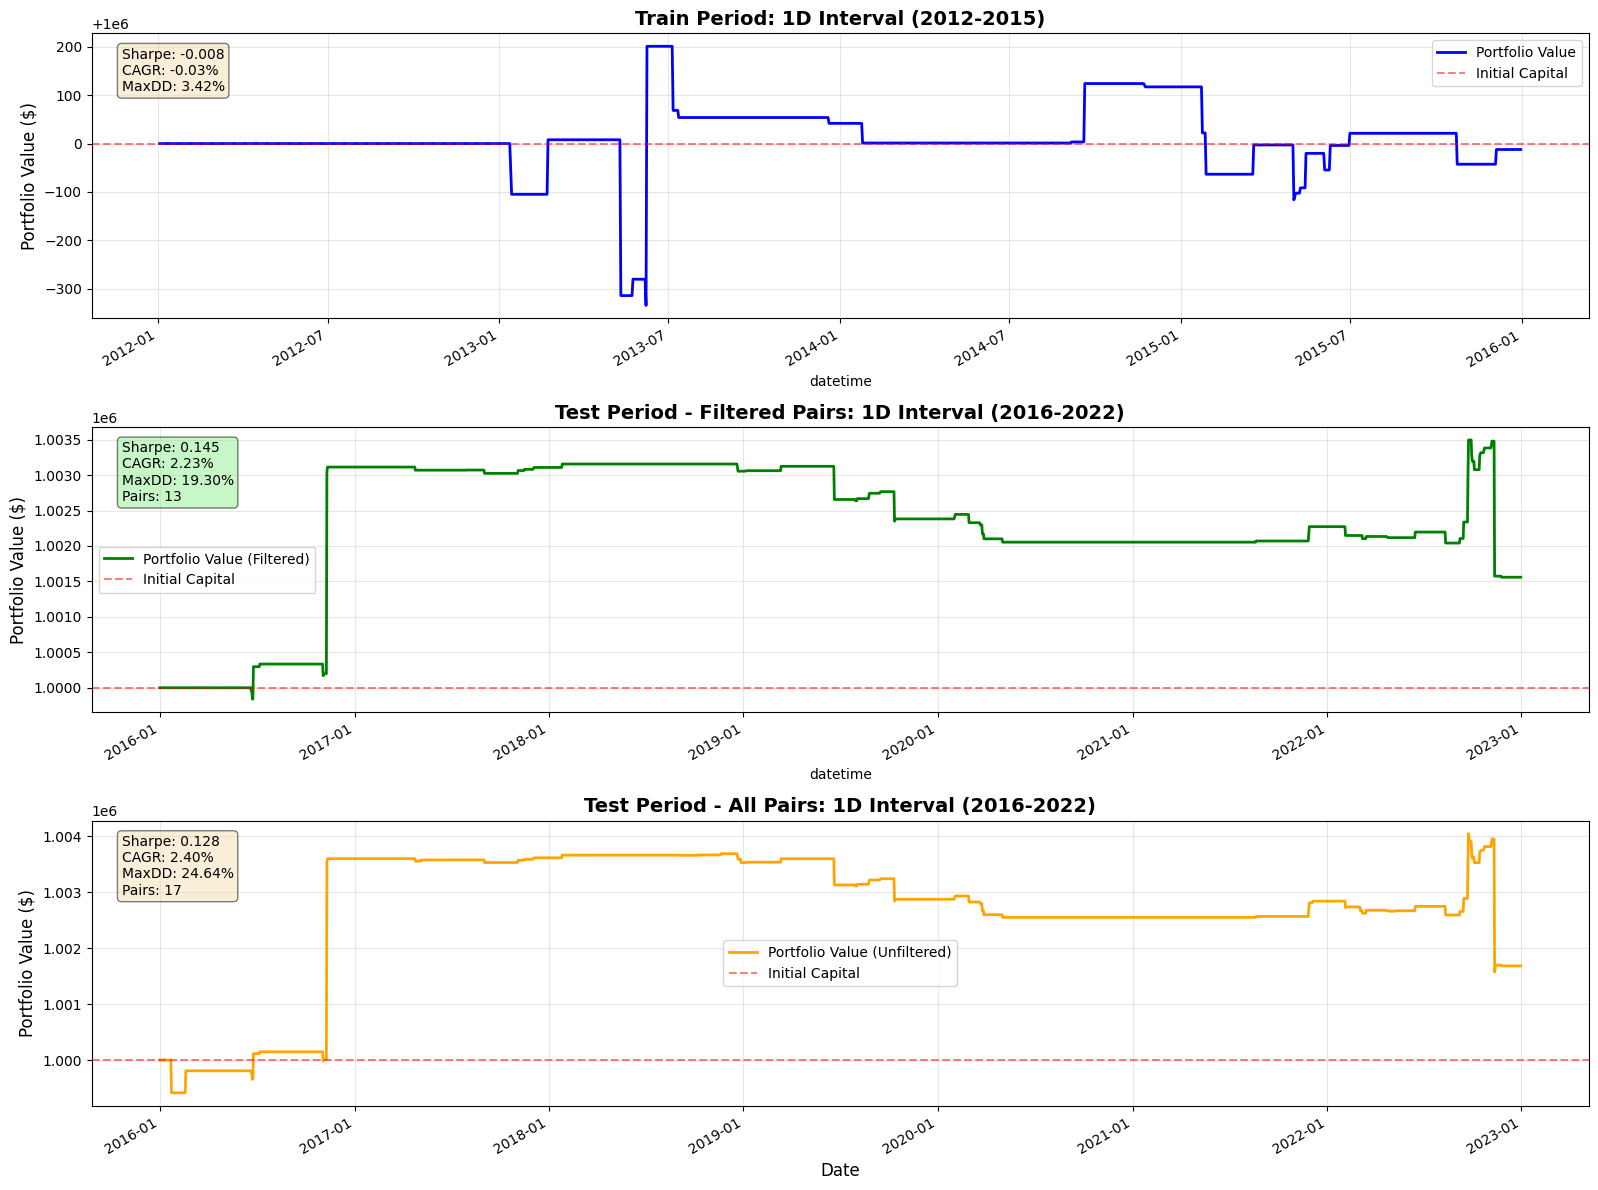


PERFORMANCE COMPARISON SUMMARY


,Period,Sharpe,CAGR (%),MaxDD (%),Total Return (%),Trades,Win Rate (%),Pairs
0,Train (2012-2015),-0.008,-0.000,0.034,-0.001,33,51.52,13
1,Test Filtered (2016-2022),0.145,0.022,0.193,0.156,81,56.79,13
2,Test Unfiltered (2016-2022),0.128,0.024,0.246,0.168,101,58.42,17


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import src.backtest.kalman as bk

# Assuming you have the following data available from previous cells:
# - Train equity curve (from '2012-01-01' to '2015-12-31')
# - Test filtered equity curve (from backtest_results[curr_interval]['equity_curve'])
# - Test unfiltered equity curve (from the last backtest run)

# First, let's run all three backtests and store results properly
curr_interval = '6H'

# 1. Train period
print("=" * 80)
print("TRAIN PERIOD (2012-01-01 to 2015-12-31)")
print("=" * 80)
train_equity_curve, train_trades_df, train_metrics = bk.backtest_universe_main(
    pairs        = final_combos[curr_interval],
    interval     = curr_interval,
    test_start   = '2012-01-01',
    test_end     = '2015-12-31',
    verbosity    = 2
)

# 2. Test period - Filtered pairs
filtered_pairs, _ = final_filter(train_trades_df)
print("\n" + "=" * 80)
print("TEST PERIOD - FILTERED (2016-01-01 to 2022-12-31)")
print("=" * 80)
test_filtered_equity_curve, test_filtered_trades_df, test_filtered_metrics = bk.backtest_universe_main(
    pairs       = filtered_pairs,
    interval    = curr_interval,
    test_start  = '2016-01-01',
    test_end    = '2022-12-31',
    verbosity   = 2
)

# 3. Test period - Unfiltered pairs
print("\n" + "=" * 80)
print("TEST PERIOD - UNFILTERED (2016-01-01 to 2022-12-31)")
print("=" * 80)
test_unfiltered_equity_curve, test_unfiltered_trades_df, test_unfiltered_metrics = bk.backtest_universe_main(
    pairs       = final_combos[curr_interval],
    interval    = curr_interval,
    test_start  = '2016-01-01',
    test_end    = '2022-12-31',
    verbosity   = 2
)

# Now plot all three equity curves
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Normalize to starting capital for comparison
initial_capital = 1_000_000

# Plot 1: Train Period
ax1 = axes[0]
train_equity_curve['portfolio_value'].plot(ax=ax1, linewidth=2, color='blue', label='Portfolio Value')
ax1.axhline(initial_capital, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
ax1.set_title(f'Train Period: {curr_interval} Interval (2012-2015)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.text(0.02, 0.95, f"Sharpe: {train_metrics['sharpe_ratio']:.3f}\nCAGR: {train_metrics['cagr_pct']:.2%}\nMaxDD: {train_metrics['max_drawdown_pct']:.2%}", 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Test Period - Filtered
ax2 = axes[1]
test_filtered_equity_curve['portfolio_value'].plot(ax=ax2, linewidth=2, color='green', label='Portfolio Value (Filtered)')
ax2.axhline(initial_capital, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
ax2.set_title(f'Test Period - Filtered Pairs: {curr_interval} Interval (2016-2022)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Portfolio Value ($)', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.text(0.02, 0.95, f"Sharpe: {test_filtered_metrics['sharpe_ratio']:.3f}\nCAGR: {test_filtered_metrics['cagr_pct']:.2%}\nMaxDD: {test_filtered_metrics['max_drawdown_pct']:.2%}\nPairs: {test_filtered_metrics['n_pairs']}", 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# Plot 3: Test Period - Unfiltered
ax3 = axes[2]
test_unfiltered_equity_curve['portfolio_value'].plot(ax=ax3, linewidth=2, color='orange', label='Portfolio Value (Unfiltered)')
ax3.axhline(initial_capital, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
ax3.set_title(f'Test Period - All Pairs: {curr_interval} Interval (2016-2022)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Portfolio Value ($)', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.text(0.02, 0.95, f"Sharpe: {test_unfiltered_metrics['sharpe_ratio']:.3f}\nCAGR: {test_unfiltered_metrics['cagr_pct']:.2%}\nMaxDD: {test_unfiltered_metrics['max_drawdown_pct']:.2%}\nPairs: {test_unfiltered_metrics['n_pairs']}", 
         transform=ax3.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(f'./plots/equity_curves_{curr_interval}_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary comparison
print("\n" + "=" * 80)
print("PERFORMANCE COMPARISON SUMMARY")
print("=" * 80)
comparison_df = pd.DataFrame({
    'Period': ['Train (2012-2015)', 'Test Filtered (2016-2022)', 'Test Unfiltered (2016-2022)'],
    'Sharpe': [train_metrics['sharpe_ratio'], test_filtered_metrics['sharpe_ratio'], test_unfiltered_metrics['sharpe_ratio']],
    'CAGR (%)': [train_metrics['cagr_pct'], test_filtered_metrics['cagr_pct'], test_unfiltered_metrics['cagr_pct']],
    'MaxDD (%)': [train_metrics['max_drawdown_pct'], test_filtered_metrics['max_drawdown_pct'], test_unfiltered_metrics['max_drawdown_pct']],
    'Total Return (%)': [train_metrics['total_return_pct'], test_filtered_metrics['total_return_pct'], test_unfiltered_metrics['total_return_pct']],
    'Trades': [train_metrics['n_real_trades'], test_filtered_metrics['n_real_trades'], test_unfiltered_metrics['n_real_trades']],
    'Win Rate (%)': [train_metrics['real_win_rate'] * 100, test_filtered_metrics['real_win_rate'] * 100, test_unfiltered_metrics['real_win_rate'] * 100],
    'Pairs': [train_metrics['n_pairs'], test_filtered_metrics['n_pairs'], test_unfiltered_metrics['n_pairs']]
})
display(comparison_df.round(3))

In [24]:
display(test_filtered_trades_df.head())

,pair,exit_time,interval,entry_price1,entry_price2,exit_price1,exit_price2,entry_spread,exit_spread,spread_change,...,half_life,bars_held,notional,eg_pval_at_entry,exit_type,spread_std,is_paper,state,portfolio_value_before,portfolio_value_after
entry_time,,,,,,,,,,,,,,,,,,,,,
2016-06-20,AUDJPY/GBPUSD,2016-06-21,1D,77.84600,1.46111,77.64700,1.46532,0.000552,0.003682,0.003131,...,29.746642,1,14914.667123,0.006619,SL,0.000184,False,LIVE,1.000000e+06,9.999560e+05
2016-06-20,EURCHF/GBPUSD,2016-06-23,1D,1.09001,1.46111,1.08767,1.47969,0.006460,0.019380,0.012920,...,25.483747,3,10000.000000,0.021602,SL,0.001981,False,LIVE,9.999560e+05,9.998401e+05
2016-06-24,EURCHF/USDCHF,2016-06-25,1D,1.06943,0.97497,1.07964,0.97230,0.002119,-0.004971,-0.007090,...,19.928059,1,9998.401264,0.048625,TP,0.000528,False,LIVE,9.998401e+05,9.998879e+05
2016-06-24,AUDJPY/EURCHF,2016-06-25,1D,73.84200,1.06943,76.43500,1.07964,-0.000153,0.008344,0.008498,...,8.311069,1,49992.006318,0.012307,TP,0.000039,False,LIVE,9.998879e+05,1.000297e+06
2016-07-06,AUDJPY/GBPUSD,2016-07-07,1D,74.93500,1.28894,75.84100,1.29571,-0.000845,0.003066,0.003911,...,23.161746,1,10858.675160,0.013084,TP,0.000256,False,LIVE,1.000297e+06,1.000334e+06


In [25]:
import pandas as pd

# Filter trades from COVID period (Feb-Apr 2020)
covid_start = pd.Timestamp('2020-02-01')
covid_end = pd.Timestamp('2020-04-30')

# Get trades from the test_filtered_trades_df (or test_unfiltered_trades_df)
covid_trades = test_filtered_trades_df[
    (test_filtered_trades_df.index >= covid_start) & 
    (test_filtered_trades_df.index <= covid_end)
].copy()

# Sort by profit (descending) to see most profitable first
covid_trades_sorted = covid_trades.sort_values('dollar_pnl_net', ascending=False)

# Select relevant columns
trade_summary = covid_trades_sorted[[
    'pair',
    # 'entry_time',
    'exit_time',
    'entry_z',
    'exit_z',
    'entry_spread',
    'exit_spread',
    'notional',
    'dollar_pnl_gross',
    'dollar_pnl_net',
    'bars_held'
]].copy()

# Add some calculated columns
trade_summary['z_score_change'] = trade_summary['entry_z'].abs() - trade_summary['exit_z'].abs()
trade_summary['holding_days'] = trade_summary['bars_held'] * 6 / 24  # 6H bars to days
trade_summary['profit_per_day'] = trade_summary['dollar_pnl_net'] / trade_summary['holding_days']

# Display top profitable trades
print("=" * 100)
print("TOP 20 MOST PROFITABLE TRADES DURING COVID (Feb-Apr 2020)")
print("=" * 100)
display(trade_summary.head(20))

# Display worst trades
print("\n" + "=" * 100)
print("TOP 10 WORST TRADES DURING COVID")
print("=" * 100)
display(trade_summary.tail(10))

# Summary statistics
print("\n" + "=" * 100)
print("COVID PERIOD TRADE STATISTICS")
print("=" * 100)
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Trades',
        'Winning Trades',
        'Losing Trades',
        'Win Rate (%)',
        'Total P&L ($)',
        'Average Trade P&L ($)',
        'Best Trade ($)',
        'Worst Trade ($)',
        'Average Entry Z-Score',
        'Average Exit Z-Score',
        'Average Holding Period (days)',
        'Average Profit per Day ($)'
    ],
    'Value': [
        len(covid_trades),
        len(covid_trades[covid_trades['dollar_pnl_net'] > 0]),
        len(covid_trades[covid_trades['dollar_pnl_net'] <= 0]),
        (covid_trades['dollar_pnl_net'] > 0).mean() * 100,
        covid_trades['dollar_pnl_net'].sum(),
        covid_trades['dollar_pnl_net'].mean(),
        covid_trades['dollar_pnl_net'].max(),
        covid_trades['dollar_pnl_net'].min(),
        covid_trades['entry_z'].abs().mean(),
        covid_trades['exit_z'].abs().mean(),
        trade_summary['holding_days'].mean(),
        trade_summary['profit_per_day'].mean()
    ]
})
display(summary_stats)

# Pair-level breakdown
print("\n" + "=" * 100)
print("PERFORMANCE BY PAIR DURING COVID")
print("=" * 100)
pair_performance = covid_trades.groupby('pair').agg({
    'dollar_pnl_net': ['count', 'sum', 'mean'],
    'entry_z': lambda x: x.abs().mean(),
    'bars_held': 'mean'
}).round(2)
pair_performance.columns = ['Trades', 'Total P&L', 'Avg P&L', 'Avg Entry |Z|', 'Avg Holding Bars']
pair_performance = pair_performance.sort_values('Total P&L', ascending=False)
display(pair_performance)

# Save detailed trades to CSV for further analysis
# covid_trades_sorted.to_csv(f'./results/covid_trades_{curr_interval}_detailed.csv', index=False)
# print(f"\nDetailed trades saved to: ./results/covid_trades_{curr_interval}_detailed.csv")

TOP 20 MOST PROFITABLE TRADES DURING COVID (Feb-Apr 2020)


,pair,exit_time,entry_z,exit_z,entry_spread,exit_spread,notional,dollar_pnl_gross,dollar_pnl_net,bars_held,z_score_change,holding_days,profit_per_day
entry_time,,,,,,,,,,,,,
2020-02-01,AUDJPY/EURAUD,2020-02-03,3.061806,-50.000000,0.000133,-0.002028,18796.557387,36.739806,34.860150,1,-46.938194,0.25,139.440601
2020-02-01,EURCHF/EURAUD,2020-02-03,3.374581,-3.609161,0.002244,-0.000115,10023.821699,20.794550,19.792167,1,-0.234580,0.25,79.168669
2020-02-01,AUDUSD/USDCHF,2020-02-03,-3.104933,6.698178,-0.000560,0.000626,10023.821699,9.556662,8.554279,1,-3.593245,0.25,34.217117
2020-03-27,EURCHF/USDCAD,2020-03-28,-4.444988,-20.169499,-0.000656,-0.003654,10021.719896,-25.261200,0.000000,1,-15.724511,0.25,0.000000
2020-04-16,EURCHF/USDCAD,2020-04-17,3.880320,-37.846426,0.000606,-0.005265,10021.009377,48.755037,0.000000,1,-33.966106,0.25,0.000000
2020-03-20,EURCHF/USDCAD,2020-03-21,-4.376424,-24.196485,-0.000613,-0.004054,10023.283089,-29.302637,-30.304965,1,-19.820061,0.25,-121.219860
2020-02-28,EURCHF/EURAUD,2020-02-29,3.615380,7.812045,0.002454,0.007670,10024.453765,-45.811178,-46.813623,1,-4.196665,0.25,-187.254493
2020-02-28,AUDJPY/EURAUD,2020-02-29,3.145031,50.000000,0.000138,0.004224,18395.372061,-68.414439,-70.253976,1,-46.854969,0.25,-281.015904
2020-03-27,EURCHF/AUDUSD,2020-03-28,4.338320,20.583655,0.002067,0.012061,10021.719896,-70.049703,-71.051875,1,-16.245335,0.25,-284.207502



TOP 10 WORST TRADES DURING COVID


,pair,exit_time,entry_z,exit_z,entry_spread,exit_spread,notional,dollar_pnl_gross,dollar_pnl_net,bars_held,z_score_change,holding_days,profit_per_day
entry_time,,,,,,,,,,,,,
2020-02-01,AUDJPY/EURAUD,2020-02-03,3.061806,-50.000000,0.000133,-0.002028,18796.557387,36.739806,34.860150,1,-46.938194,0.25,139.440601
2020-02-01,EURCHF/EURAUD,2020-02-03,3.374581,-3.609161,0.002244,-0.000115,10023.821699,20.794550,19.792167,1,-0.234580,0.25,79.168669
2020-02-01,AUDUSD/USDCHF,2020-02-03,-3.104933,6.698178,-0.000560,0.000626,10023.821699,9.556662,8.554279,1,-3.593245,0.25,34.217117
2020-03-27,EURCHF/USDCAD,2020-03-28,-4.444988,-20.169499,-0.000656,-0.003654,10021.719896,-25.261200,0.000000,1,-15.724511,0.25,0.000000
2020-04-16,EURCHF/USDCAD,2020-04-17,3.880320,-37.846426,0.000606,-0.005265,10021.009377,48.755037,0.000000,1,-33.966106,0.25,0.000000
2020-03-20,EURCHF/USDCAD,2020-03-21,-4.376424,-24.196485,-0.000613,-0.004054,10023.283089,-29.302637,-30.304965,1,-19.820061,0.25,-121.219860
2020-02-28,EURCHF/EURAUD,2020-02-29,3.615380,7.812045,0.002454,0.007670,10024.453765,-45.811178,-46.813623,1,-4.196665,0.25,-187.254493
2020-02-28,AUDJPY/EURAUD,2020-02-29,3.145031,50.000000,0.000138,0.004224,18395.372061,-68.414439,-70.253976,1,-46.854969,0.25,-281.015904
2020-03-27,EURCHF/AUDUSD,2020-03-28,4.338320,20.583655,0.002067,0.012061,10021.719896,-70.049703,-71.051875,1,-16.245335,0.25,-284.207502



COVID PERIOD TRADE STATISTICS


,Metric,Value
0,Total Trades,10.000000
1,Winning Trades,3.000000
2,Losing Trades,7.000000
3,Win Rate (%),30.000000
4,Total P&L ($),-281.232178
5,Average Trade P&L ($),-28.123218
6,Best Trade ($),34.860150
7,Worst Trade ($),-126.014335
8,Average Entry Z-Score,3.642433
9,Average Exit Z-Score,23.277437



PERFORMANCE BY PAIR DURING COVID


,Trades,Total P&L,Avg P&L,Avg Entry |Z|,Avg Holding Bars
pair,,,,,
AUDUSD/USDCHF,1,8.55,8.55,3.10,1.0
EURCHF/USDCAD,3,-30.30,-10.10,4.23,1.0
AUDJPY/EURAUD,2,-35.39,-17.70,3.10,1.0
EURCHF/AUDUSD,1,-71.05,-71.05,4.34,1.0
EURCHF/EURAUD,3,-153.04,-51.01,3.36,1.0


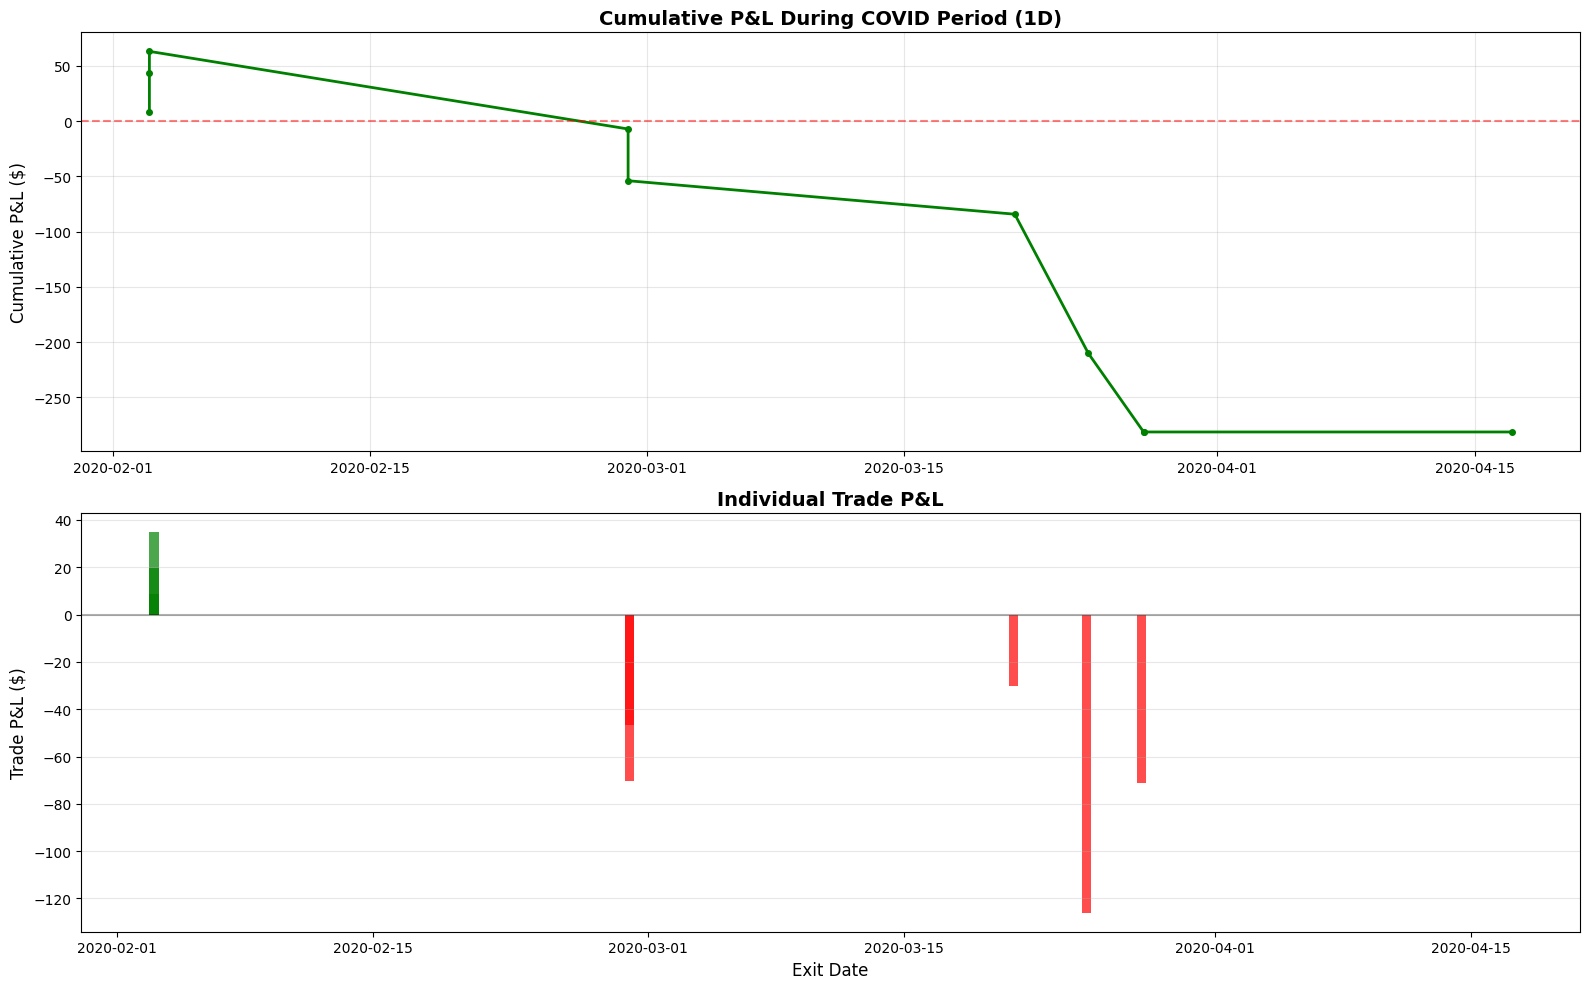

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Plot cumulative P&L during COVID period
covid_trades_timeline = covid_trades.sort_values('exit_time').copy()
covid_trades_timeline['cumulative_pnl'] = covid_trades_timeline['dollar_pnl_net'].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Cumulative P&L over time
ax1 = axes[0]
ax1.plot(covid_trades_timeline['exit_time'], 
         covid_trades_timeline['cumulative_pnl'], 
         linewidth=2, color='green', marker='o', markersize=4)
ax1.set_title(f'Cumulative P&L During COVID Period ({curr_interval})', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cumulative P&L ($)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)

# Plot 2: Individual trade P&L
ax2 = axes[1]
colors = ['green' if x > 0 else 'red' for x in covid_trades_timeline['dollar_pnl_net']]
ax2.bar(covid_trades_timeline['exit_time'], 
        covid_trades_timeline['dollar_pnl_net'],
        color=colors, alpha=0.7, width=0.5)
ax2.set_title('Individual Trade P&L', fontsize=14, fontweight='bold')
ax2.set_ylabel('Trade P&L ($)', fontsize=12)
ax2.set_xlabel('Exit Date', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.axhline(0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
# plt.savefig(f'./plots/covid_trades_analysis_{curr_interval}.png', dpi=300, bbox_inches='tight')
plt.show()

# print(f"\nVisualization saved to: ./plots/covid_trades_analysis_{curr_interval}.png")